# Show Reel — Community Persona Pipeline (Vertex AI **Synchronous** + **Multimodal**)

**Platform:** Instagram   **Runtime:** Google Colab Enterprise / Vertex AI (ADC auth)

This pipeline runs both LLM stages as **synchronous `generate_content` calls** via the unified
`google-genai` SDK, parallelised with a `ThreadPoolExecutor` (~8 workers) for throughput.
Results are checkpointed to disk line-by-line so a crash or interrupt is fully resumable.

Persona identification is **multimodal**: each user request carries the media of the posts they
engage with most, read straight from GCS via `gs://` `fileData` parts —
- **image / carousel** posts → the photo(s) + metadata (tagged users, music, caption);
- **reel / feed / carousel_video** posts → the sampled `frames/*.jpg` + the `transcription.txt` + metadata.

**Flow:** Stage 0 features → Stage 1 taxonomy discovery (Flash, synchronous) → human approval →


## Install Dependencies

Run once per runtime, then restart the kernel. The unified `google-genai` SDK drives both the
batch jobs and the online connectivity test; `google-cloud-storage` handles GCS upload/list/download.

In [13]:
!pip install -q google-genai google-cloud-storage gcsfs pandas pyarrow tqdm emoji

## Configuration

Everything environment- and cost-related lives here. The multimodal caps (`MAX_MEDIA_POSTS_PER_USER`,
`MAX_IMAGES_PER_POST`) directly drive token cost — raise them for richer context, lower them to save money.

In [1]:
import os

# ============================ PLATFORM TOGGLE ============================
# Run the whole persona pipeline against a different platform by changing this.
# Comments come from the multi-platform prepared exports and are filtered to PLATFORM.
PLATFORM = "instagram"        # instagram | youtube | tiktok | facebook
# ========================================================================

# GCP / Vertex AI
GCP_PROJECT_ID = "project-a9b99a62-b082-46aa-b54"
GCP_LOCATION   = "us-central1"   # batch prediction: better Gemini batch quota/throughput
GCS_BUCKET     = "afb_project2_us"   # us-central1 bucket for batch I/O (must match GCP_LOCATION)

# --- Prepared comments (ALL platforms; filtered to PLATFORM at load) -----------
# comments_ml      : numeric features + bare-numeric author_id/media_id + comment_id (ig_comment_<n>)
# edges_replies_to : reply structure (src --replies to--> dst), joined on comment_id
# comments_llm     : raw text keyed by comment_id (no author_id -> join via comment_id)
COMMENTS_ML_PATH   = "outputs/comments_ml.parquet"
COMMENTS_LLM_PATH  = "outputs/comments_llm.jsonl"
EDGES_REPLIES_PATH = "outputs/edges_replies_to.parquet"

# --- Multimodal context (Instagram only): post metadata + media on GCS ---------
# ig_multimodal_final bridges media_id <-> shortcode and carries post metadata
# (tagged users, music, caption); media objects live under MEDIA_GCS_PREFIX.
MEDIA_INDEX_PATH = "outputs/ig_multimodal_final.parquet"
MEDIA_GCS_PREFIX = "multimodal_dataset_fixed/"     # gs://bucket/<prefix>/<form>/<shortcode>/...
ATTACH_MEDIA     = False  #(PLATFORM == "instagram")        # media context is wired for IG; others run comments-only

# Models — Flash discovers the taxonomy on a sample, Pro classifies the full set.
MODEL_STAGE1_EXPLORATORY = "gemini-2.5-flash"
MODEL_STAGE2_CLASSIFY    = "gemini-2.5-flash"

# Determinism (academic reproducibility)
TEMPERATURE              = 0.0
TOP_P                    = 1.0
# Gemini 2.5 are THINKING models: thinking tokens count against maxOutputTokens, so these must be
# big enough for (thinking + JSON output) or the response truncates (finishReason=MAX_TOKENS).
MAX_OUTPUT_TOKENS_STAGE1 = 24576   # raised: 8192 truncated multi-persona JSON arrays mid-string
MAX_OUTPUT_TOKENS_STAGE2 = 8192   # raised: now returns an ARRAY of STAGE2_USERS_PER_REQUEST objects
THINKING_BUDGET_STAGE1   = 1024   # Flash: cap thinking so the JSON array always completes (0 = disable)
THINKING_BUDGET_STAGE2   = 512    # Pro:   min 128; keep modest for cost across many requests

# Pipeline mode:  SAMPLE = Stage 0+1 (discover, then pause for approval)
#                 FULL   = Stage 0+2 (classify, needs APPROVED taxonomy)
#                 ALL    = both in sequence

# Sampling / batching
SAMPLE_N_USERS           = 20000
SAMPLE_SEED              = 42
STAGE1_USERS_PER_REQUEST = 3
STAGE2_USERS_PER_REQUEST = 3   # pack N users/request; 3 = low label-hallucination, 3x fewer requests
MAX_BATCH_TOKENS         = 900_000   # stay under Vertex 1M token limit; each job gets split
STAGE2_MAX_USERS         = None

# Multimodal attachment caps (cost control)
MAX_MEDIA_POSTS_PER_USER = 2
MAX_IMAGES_PER_POST      = 2
INCLUDE_TRANSCRIPT       = True
MAX_TRANSCRIPT_CHARS     = 1500

# Batch I/O on GCS
BATCH_INPUT_PREFIX    = "persona_batch/input/"
BATCH_OUTPUT_PREFIX   = "persona_batch/output/"
POLL_INTERVAL_SECONDS = 60

# Local artifacts (uploaded to GCS after the run)
LOCAL_DIR          = "outputs/stage1_persona"
TAXONOMY_JSON_PATH = f"{LOCAL_DIR}/taxonomy.json"
TAXONOMY_A_PATH    = f"{LOCAL_DIR}/taxonomy_pathwayA.json"  # LLM consolidation output
TAXONOMY_B_PATH    = f"{LOCAL_DIR}/taxonomy_pathwayB.json"  # UMAP/HDBSCAN output
RESULTS_PATH       = f"outputs/stage2_persona/user_personas.parquet"  # Stage 2 output
PERSONA_MAP_PATH   = f"outputs/stage2_persona/persona_map_{PLATFORM}.parquet"  # author_id -> persona_codename
os.makedirs(LOCAL_DIR, exist_ok=True)


# --- Sentiment pipeline outputs (consumed by Stage 0 room-vibe enrichment) ----
# sentiment_<platform>.parquet is written by sentiment_pipeline.ipynb retrieve step.
# post_vibes.parquet is a post-level summary derived from it (one row per media_id).
SENTIMENT_PATH  = f"outputs/stage2_sentiment/sentiment_{PLATFORM}.parquet"  # from sentiment_pipeline
STRATIFY_BY_SENTIMENT      = True
SENTIMENT_STRATA_COL       = "sentiment"   # column in sentiment parquet to stratify on
TARGET_PERSONAS            = 12          # canonical taxonomy size (shared by Pathway A & B)
POST_VIBES_PATH = f"outputs/stage2_sentiment/post_vibes_{PLATFORM}.parquet"  # from sentiment_pipeline

print("✅ Configuration loaded.")
print(f"   Platform: {PLATFORM}  (media context: {'ON' if ATTACH_MEDIA else 'OFF'})")
print(f"   Bucket:   gs://{GCS_BUCKET}")


✅ Configuration loaded.
   Platform: instagram  (media context: OFF)
   Bucket:   gs://afb_project2_us


## Vertex AI Client (google-genai)

`genai.Client(vertexai=True, ...)` flips the unified SDK to the Vertex backend (IAM/ADC auth, GCS
I/O, regional endpoints) — the same client submits batch jobs and runs the online connectivity test.

In [2]:
from google import genai
from google.genai import types
from google.genai.types import CreateBatchJobConfig, JobState

client = genai.Client(vertexai=True, project=GCP_PROJECT_ID, location=GCP_LOCATION)

def gen_config_dict(max_tokens: int, thinking_budget: int | None = None) -> dict:
    """Per-request generationConfig (camelCase REST keys) embedded in each JSONL line.
    responseMimeType forces JSON; thinkingConfig caps the 2.5 models' thinking-token spend so
    the visible output isn't starved (the MAX_TOKENS truncation bug)."""
    cfg = {
        "temperature": TEMPERATURE,
        "topP": TOP_P,
        "maxOutputTokens": max_tokens,
        "responseMimeType": "application/json",
    }
    if thinking_budget is not None:
        cfg["thinkingConfig"] = {"thinkingBudget": thinking_budget}
    return cfg

def gen_config_obj(max_tokens: int, thinking_budget: int | None = None) -> types.GenerateContentConfig:
    """GenerateContentConfig for synchronous client.models.generate_content calls."""
    thinking = (types.ThinkingConfig(thinking_budget=thinking_budget)
                if thinking_budget is not None else None)
    return types.GenerateContentConfig(
        temperature=TEMPERATURE,
        top_p=TOP_P,
        max_output_tokens=max_tokens,
        response_mime_type="application/json",
        thinking_config=thinking,
    )

print("✅ genai Vertex client ready:", GCP_PROJECT_ID, GCP_LOCATION)


✅ genai Vertex client ready: project-a9b99a62-b082-46aa-b54 us-central1


## Data Loading

Persona features come from the **comments dataset** — the multi-platform prepared exports, filtered
to `PLATFORM`:
- `Preped_Comments/comments_ml.parquet` — per-comment numeric features + bare-numeric `author_id`/`media_id`
- `HeteroGraph/edges_replies_to.parquet` — reply structure (`src --replies to--> dst`), joined on `comment_id`

For Instagram, `ig_multimodal_final.parquet` (post metadata + `media_id`↔`shortcode`) and the GCS media
are loaded as **multimodal context** only. Other platforms run comments-only.

In [3]:
import pandas as pd

print(f"Loading prepared comments for platform = {PLATFORM!r}")

# 1) Comment feature matrix — predicate-pushdown filter to PLATFORM (skips other platforms).
ig_comments = pd.read_parquet(COMMENTS_ML_PATH, filters=[("platform", "==", PLATFORM)])
ig_comments["author_id"] = ig_comments["author_id"].astype(str)
ig_comments["media_id"]  = ig_comments["media_id"].astype(str)
print(f"  comments_ml[{PLATFORM}]: {len(ig_comments):,} comments | "
      f"{ig_comments['author_id'].nunique():,} authors | {ig_comments['media_id'].nunique():,} media")

# 2) Reply structure: edges_replies_to (src --replies to--> dst), joined on comment_id.
try:
    replies = pd.read_parquet(EDGES_REPLIES_PATH, filters=[("platform", "==", PLATFORM)],
                              columns=["src_comment_id", "dst_comment_id"])
    replies = (replies.rename(columns={"src_comment_id": "comment_id",
                                       "dst_comment_id": "reply_to_comment_id"})
                      .drop_duplicates("comment_id"))
    ig_comments = ig_comments.merge(replies, on="comment_id", how="left")
    print(f"  reply edges: {len(replies):,} | replies flagged on "
          f"{ig_comments['reply_to_comment_id'].notna().sum():,} comments")
except Exception as e:
    print("  ⚠️  edges_replies_to unavailable -> no reply features:", str(e)[:120])
    ig_comments["reply_to_comment_id"] = pd.NA

# 3) Instagram-only multimodal context: post metadata + media index.
if ATTACH_MEDIA:
    media_index = pd.read_parquet(MEDIA_INDEX_PATH)
    media_index = media_index[media_index["media_id"].notna()].copy()
    media_index["media_id"] = media_index["media_id"].astype(str)
    ig_media = media_index                      # post-metadata source for Stage 0 temporal features
    print(f"  media_index: {len(media_index):,} posts | {media_index['shortcode'].nunique():,} shortcodes")
else:
    media_index = None
    ig_media = None
    print(f"  media context OFF for platform={PLATFORM} -> comments-only run")

# 4) Validation
n_before = len(ig_comments)
ig_comments = ig_comments[ig_comments["author_id"].notna() & (ig_comments["author_id"] != "")].copy()
print(f"\n✅ Comments ready: {len(ig_comments):,}/{n_before:,} | "
      f"unique authors: {ig_comments['author_id'].nunique():,}")

Loading prepared comments for platform = 'instagram'
  comments_ml[instagram]: 499,752 comments | 194,513 authors | 1,501 media
  ⚠️  edges_replies_to unavailable -> no reply features: [Errno 2] No such file or directory: 'outputs/edges_replies_to.parquet'
  media context OFF for platform=instagram -> comments-only run

✅ Comments ready: 499,752/499,752 | unique authors: 194,513


## Stage 0 — Feature Engineering

All comment-level features (word count, emoji count, etc.) are pre-computed upstream. Here we derive
binary flags + temporal features, aggregate to one row per `author_id`, and attach each user's
representative comment text.

In [4]:
# ── canonical 3-class sentiment ───────────────────────────────────────────────
# The sentiment LLM occasionally returns free-form emotion labels instead of the
# 3-class schema. canon_sentiment() collapses any Series to positive/neutral/negative
# so stratification, the user-sentiment cache, and the plots all agree.
SENT_CANON_MAP = {
    "positive": "positive", "negative": "negative", "neutral": "neutral",
    "amused": "positive", "amusement": "positive", "joke": "positive",
    "joy": "positive", "support": "positive", "supportive": "positive",
    "affection": "positive", "anticipation": "positive",
    "sarcastic": "negative", "sarcasm": "negative", "sadness": "negative",
    "question": "neutral", "suggestion": "neutral", "surprise": "neutral",
    "mixed": "neutral", "spam": "neutral",
}
def canon_sentiment(series):
    s = series.astype(str).str.strip().str.lower()
    return s.map(SENT_CANON_MAP).fillna("neutral")

import numpy as np
from datetime import timedelta
import os

# === FEATURE ENGINEERING (always runs) ===
# 1. Binary flags from pre-computed counts
ig_comments["has_emoji"]    = (ig_comments["emoji_count"] > 0).astype(int)
ig_comments["has_question"] = (ig_comments["question_count"] > 0).astype(int)
ig_comments["has_exclaim"]  = (ig_comments["exclamation_count"] > 0).astype(int)
ig_comments["is_reply"]     = ig_comments["reply_to_comment_id"].notna().astype(int)
print("Binary flags derived.")

# Join per-comment sentiment/toxicity from sentiment pipeline output.
# sentiment_score: -1 (very negative) -> +1 (very positive)
# is_toxic: 1 if toxicity in {mild, severe}
# is_negative: 1 if sentiment == negative
_sent_path = SENTIMENT_PATH
if os.path.exists(_sent_path):
    _sent = pd.read_parquet(
        _sent_path,
        columns=["comment_id", "sentiment_score", "toxicity", "sentiment"],
    )
    # collapse free-form emotion labels to canonical 3-class (see canon_sentiment)
    _sent["sentiment"] = canon_sentiment(_sent["sentiment"])
    _sent["is_toxic"]    = _sent["toxicity"].isin(["mild", "severe"]).astype(int)
    _sent["is_negative"] = (_sent["sentiment"] == "negative").astype(int)
    ig_comments = ig_comments.merge(
        _sent[["comment_id", "sentiment_score", "is_toxic", "is_negative"]],
        on="comment_id", how="left",
    )
    ig_comments["sentiment_score"] = ig_comments["sentiment_score"].fillna(0.0)
    ig_comments["is_toxic"]        = ig_comments["is_toxic"].fillna(0).astype(int)
    ig_comments["is_negative"]     = ig_comments["is_negative"].fillna(0).astype(int)
    _n_sent = _sent["comment_id"].nunique()
    print(f"Sentiment joined: {_n_sent:,} comments enriched.")
else:
    ig_comments["sentiment_score"] = 0.0
    ig_comments["is_toxic"]        = 0
    ig_comments["is_negative"]     = 0
    print(f"WARNING: {_sent_path} not found — sentiment features will be zero.")
# Guard: ensure columns exist even if the branch above was skipped for any reason.
for _col, _default in [("sentiment_score", 0.0), ("is_toxic", 0), ("is_negative", 0)]:
    if _col not in ig_comments.columns:
        ig_comments[_col] = _default

# 2. Temporal features vs. post time (uses Instagram post metadata when available)
ig_comments["timestamp"] = pd.to_datetime(ig_comments["timestamp"], errors="coerce", utc=True)
if ATTACH_MEDIA and ig_media is not None and "timestamp" in ig_media.columns:
    pm = ig_media[["media_id", "timestamp"]].rename(columns={"timestamp": "post_timestamp"})
    ig_comments = ig_comments.drop(columns=[c for c in ["post_timestamp","hours_to_comment"] if c in ig_comments.columns])
    ig_comments = ig_comments.merge(pm, on="media_id", how="left")
    ig_comments["post_timestamp"]  = pd.to_datetime(ig_comments["post_timestamp"], errors="coerce", utc=True)
    ig_comments["hours_to_comment"] = (
        (ig_comments["timestamp"] - ig_comments["post_timestamp"]).dt.total_seconds() / 3600
    ).clip(lower=0)
else:
    ig_comments["hours_to_comment"] = np.nan
    print("   (no post metadata -> hours_to_comment = NaN)")


# === CACHED AGGREGATION (user_features computation) ===
USER_FEATURES_CACHE_PATH = f"{LOCAL_DIR}/user_features_{PLATFORM}_cache.parquet"

if os.path.exists(USER_FEATURES_CACHE_PATH):
    print(f"Loading cached user_features from {USER_FEATURES_CACHE_PATH} ...")
    user_features = pd.read_parquet(USER_FEATURES_CACHE_PATH)
    print(f"✓ Cached user_features loaded: {len(user_features):,} users")
else:
    print("Computing user_features (no cache found) ...")
    
    # 3. Room-vibe enrichment — load post-level sentiment summary from sentiment pipeline output
    import logging
    
    _log = logging.getLogger("persona_pipeline")
    
    def load_post_vibes(path: str) -> "pd.DataFrame | None":
        """
        Load post-level room-vibe metrics written by sentiment_pipeline.ipynb.
        Expected columns: media_id, room_vibe, room_consensus, stance_alignment.
        Returns None (and logs a warning) if the file is absent — pipeline continues
        without room-vibe features so it does not block pre-sentiment runs.
        """
        if not os.path.exists(path):
            _log.warning(
                "POST_VIBES_PATH not found (%s) — room-vibe features will be absent. "
                "Run sentiment_pipeline retrieve step first.", path
            )
            return None
        df = pd.read_parquet(path, columns=["media_id", "room_vibe", "room_consensus", "stance_alignment"])
        df["media_id"] = df["media_id"].astype(str)
        _log.info("post_vibes loaded: %d posts", len(df))
        return df
    
    _post_vibes = load_post_vibes(POST_VIBES_PATH)
    
    
    # 4. User-level aggregation
    def build_user_feature_matrix(df: pd.DataFrame, post_vibes: "pd.DataFrame | None" = None) -> pd.DataFrame:
        grp = df.groupby("author_id")
        agg = {
            "total_comments":          grp.size(),
            "unique_posts_commented":  grp["media_id"].nunique(),
            "total_replies_made":      grp["is_reply"].sum(),
            "reply_ratio":             grp["is_reply"].mean(),
            "mean_hours_to_comment":   grp["hours_to_comment"].mean(),
            "median_hours_to_comment": grp["hours_to_comment"].median(),
            "pct_comments_under_1h":   grp["hours_to_comment"].apply(lambda x: (x < 1).mean()),
            "pct_comments_under_24h":  grp["hours_to_comment"].apply(lambda x: (x < 24).mean()),
            "activity_span_days":      grp["timestamp"].apply(lambda x: (x.max() - x.min()).days if x.notna().any() else 0),
            "mean_word_count":         grp["word_count"].mean(),
            "mean_mention_count":      grp["mention_count"].mean(),
            "emoji_usage_rate":        grp["has_emoji"].mean(),
            "question_rate":           grp["has_question"].mean(),
            "exclamation_rate":        grp["has_exclaim"].mean(),
            "mean_sentiment_score":    grp["sentiment_score"].mean(),
            "pct_negative":            grp["is_negative"].mean(),
            "toxicity_rate":           grp["is_toxic"].mean(),
        }
        feat = pd.DataFrame(agg).reset_index()
        feat["post_concentration_ratio"] = (
            feat["unique_posts_commented"] / feat["total_comments"]
        ).clip(upper=1.0)
        # Fill timing features that are NaN when post metadata is absent (non-IG platforms).
        for c in ["mean_hours_to_comment", "median_hours_to_comment",
                  "pct_comments_under_1h", "pct_comments_under_24h"]:
            feat[c] = feat[c].fillna(0)

        # ── Room-vibe enrichment (IG only; skipped gracefully when post_vibes is None) ──
        if post_vibes is not None:
            # Join comments to per-post vibe metrics, then aggregate per user.
            enriched = df[["author_id", "media_id"]].merge(
                post_vibes, on="media_id", how="left"
            )
            vibe_grp = enriched.groupby("author_id")

            # mean consensus and sponsorship tolerance across posts the user engaged with
            feat = feat.merge(
                vibe_grp["room_consensus"].mean().rename("mean_engaged_consensus"),
                on="author_id", how="left"
            )
            feat = feat.merge(
                vibe_grp["stance_alignment"].mean().rename("mean_sponsorship_tolerance"),
                on="author_id", how="left"
            )
            # dominant vibe: the single most-frequent room_vibe across that user's engaged posts
            dominant_vibe = (
                vibe_grp["room_vibe"]
                .agg(lambda s: s.dropna().mode().iloc[0] if s.notna().any() else "neutral")
                .rename("dominant_room_vibe")
            )
            feat = feat.merge(dominant_vibe, on="author_id", how="left")
            feat["dominant_room_vibe"] = feat["dominant_room_vibe"].fillna("neutral").astype(str)

            n_enriched = feat["mean_engaged_consensus"].notna().sum()
            _log.info("room-vibe features attached for %d / %d users", n_enriched, len(feat))
            print(f"  room-vibe enrichment: {n_enriched:,}/{len(feat):,} users have vibe data")
        else:
            # Sentinel columns so downstream cells don't KeyError when vibes are unavailable.
            feat["mean_engaged_consensus"]    = np.nan
            feat["mean_sponsorship_tolerance"] = np.nan
            feat["dominant_room_vibe"]         = "neutral"
            print("  room-vibe enrichment skipped (post_vibes not loaded)")

        return feat


    user_features = build_user_feature_matrix(ig_comments, post_vibes=_post_vibes)
    print(f"User feature matrix built: {len(user_features):,} users.")
    
    # 5. Attach representative comment text from comments_llm (filter to PLATFORM, join by comment_id)
    print(f"Loading comment text from {COMMENTS_LLM_PATH} ...")
    _text_chunks = []
    for _chunk in pd.read_json(COMMENTS_LLM_PATH, lines=True, chunksize=200_000):
        if "platform" in _chunk.columns:
            _chunk = _chunk[_chunk["platform"] == PLATFORM]
        if len(_chunk):
            _text_chunks.append(_chunk[["comment_id", "text"]])
    llm_text = (pd.concat(_text_chunks, ignore_index=True)
                if _text_chunks else pd.DataFrame(columns=["comment_id", "text"]))

    txt = ig_comments[["comment_id", "author_id"]].merge(llm_text, on="comment_id", how="inner")
    top_comments = (
        txt.groupby("author_id").head(20)
           .groupby("author_id")["text"]
           .apply(lambda ts: " ||| ".join(ts.astype(str).tolist()))
           .reset_index()
           .rename(columns={"text": "top_comments_sample"})
    )
    user_features = user_features.merge(top_comments, on="author_id", how="left")
    print(f"Representative comment history attached for {top_comments.shape[0]:,} users.")
    
    # === SAVE CACHE ===
    user_features.to_parquet(USER_FEATURES_CACHE_PATH, index=False)
    print(f"✓ Cached user_features to {USER_FEATURES_CACHE_PATH}")


Binary flags derived.
Sentiment joined: 487,604 comments enriched.
   (no post metadata -> hours_to_comment = NaN)
Loading cached user_features from outputs/stage1_persona/user_features_instagram_cache.parquet ...
✓ Cached user_features loaded: 194,513 users


## Feature Selection for Clustering

Below are **all available features** from the comment-level data and user-level aggregations.

In [5]:
if "user_features" not in dir():
    raise RuntimeError("Run the Stage 0 feature-engineering cell first (cell that calls build_user_feature_matrix).")
# ALL AVAILABLE FEATURES FROM STAGE 0
all_available = {
    "Volume & Breadth": [
        "total_comments",
        #"unique_posts_commented",
        #"activity_span_days",
    ],
    "Reply Behavior": [
        "total_replies_made",
        "reply_ratio",
    ],
    # "Timing & Recency": [
    #     "mean_hours_to_comment",
    #     "median_hours_to_comment",
    #     "pct_comments_under_1h",
    #     "pct_comments_under_24h",
    # ],
    "Textual Style": [
        "mean_word_count",
        "mean_mention_count",
        "emoji_usage_rate",
        "question_rate",
        "exclamation_rate",
    ],
    "Concentration": [
        "post_concentration_ratio",
    ],
}

# Display grouped
total_count = 0
for category, features in all_available.items():
    print(f"{category}:")
    for f in features:
        avail = f'✓' if f in user_features.columns else '✗ (missing)'
        print(f"  {avail}  {f}")
        total_count += 1

print(f"Total available: {total_count}")

Volume & Breadth:
  ✓  total_comments
Reply Behavior:
  ✓  total_replies_made
  ✓  reply_ratio
Textual Style:
  ✓  mean_word_count
  ✓  mean_mention_count
  ✓  emoji_usage_rate
  ✓  question_rate
  ✓  exclamation_rate
Concentration:
  ✓  post_concentration_ratio
Total available: 9


In [6]:
if "user_features" not in dir():
    raise RuntimeError("Run the Stage 0 feature-engineering cell first (cell that calls build_user_feature_matrix).")
# EDIT THIS LIST: Remove or comment out features you don't want in clustering
SELECTED_NUMERIC_FEATURES = [
    "total_comments",
    #"unique_posts_commented",
    "activity_span_days",
    # "total_replies_made",  # <- REDUNDANT: use reply_ratio instead
    "reply_ratio",
    #"mean_hours_to_comment",
    # "median_hours_to_comment",  # <- REDUNDANT: use mean instead
    "pct_comments_under_1h",
    # "pct_comments_under_24h",  # <- OPTIONAL: tight subset of 1h signal
    "mean_word_count",
    "mean_mention_count",
    "emoji_usage_rate",
    "question_rate",
    "exclamation_rate",
    "post_concentration_ratio",
    "mean_sentiment_score",   # average sentiment polarity per user (-1 negative, +1 positive)
    "pct_negative",           # share of comments flagged negative
    "toxicity_rate",          # share of comments flagged toxic (mild or severe)
]

# Filter to only columns that exist
SELECTED_NUMERIC_FEATURES = [c for c in SELECTED_NUMERIC_FEATURES if c in user_features.columns]

print(f"✅ Selected {len(SELECTED_NUMERIC_FEATURES)} numeric features:")
for f in SELECTED_NUMERIC_FEATURES:
    print(f"   • {f}")

✅ Selected 13 numeric features:
   • total_comments
   • activity_span_days
   • reply_ratio
   • pct_comments_under_1h
   • mean_word_count
   • mean_mention_count
   • emoji_usage_rate
   • question_rate
   • exclamation_rate
   • post_concentration_ratio
   • mean_sentiment_score
   • pct_negative
   • toxicity_rate


## Multimodal Media Context

Builds the bridge from a commenter to the **media they engage with**:

1. `user_top_posts` — each `author_id`'s top-N most-commented `media_id`s.
2. media index maps — `media_id → shortcode` and `shortcode → post metadata`.
3. `build_media_manifest()` lists the GCS media tree **once** and groups every `gs://` object by
   shortcode into `images` (jpg/png) and `transcripts` (transcription.txt).
4. `build_user_media_parts(author_id)` emits the multipart payload (metadata text + image `fileData`
   parts + transcript text) that gets attached to that user's Stage 1 / Stage 2 request.

In [7]:
import numpy as np
from google.cloud import storage

if not ATTACH_MEDIA:
    # Non-Instagram platform: no media context — requests are text-only.
    user_top_posts = {}
    media_images, media_transcripts = {}, {}
    def build_user_media_parts(author_id) -> list:
        return []
    print(f"⏭  Media context disabled for platform={PLATFORM}; requests will be text-only.")
else:
    def _norm_id(x):
        """media_id can arrive as int, float (123.0) or str — normalise to a bare digit string."""
        s = str(x)
        return s[:-2] if s.endswith(".0") else s

    # 1) media index maps (bare-numeric media_id matches comments_ml.media_id)
    _mi = media_index[media_index["media_id"].notna()].copy()
    _mi["media_id"] = _mi["media_id"].map(_norm_id)
    _mediaid_to_shortcode = dict(zip(_mi["media_id"], _mi["shortcode"]))
    _meta_by_shortcode    = {r["shortcode"]: r for r in _mi.to_dict("records")}

    # 2) per-user top engaged posts (by comment volume)
    _tp = ig_comments[["author_id", "media_id"]].dropna().copy()
    _tp["author_id"] = _tp["author_id"].astype(str)
    _tp["media_id"]  = _tp["media_id"].map(_norm_id)
    _counts = (
        _tp.groupby(["author_id", "media_id"]).size()
           .reset_index(name="n")
           .sort_values(["author_id", "n"], ascending=[True, False])
    )
    user_top_posts = (
        _counts.groupby("author_id")["media_id"]
               .apply(lambda s: list(s.head(MAX_MEDIA_POSTS_PER_USER)))
               .to_dict()
    )
    print(f"✅ user_top_posts computed for {len(user_top_posts):,} users.")

    # 3) GCS media manifest — one list pass over the whole media tree
    def build_media_manifest(bucket=GCS_BUCKET, prefix=MEDIA_GCS_PREFIX):
        c = storage.Client(project=GCP_PROJECT_ID)
        images, transcripts = {}, {}
        for blob in c.list_blobs(bucket, prefix=prefix):
            name = blob.name
            low  = name.lower()
            segs = name.split("/")          # multimodal_dataset_fixed/<form>/<shortcode>/...
            if len(segs) < 3:
                continue
            sc  = segs[2]
            uri = f"gs://{bucket}/{name}"
            if low.endswith((".jpg", ".jpeg", ".png")):
                images.setdefault(sc, []).append(uri)
            elif low.endswith(".txt") and "transcri" in low:
                transcripts.setdefault(sc, []).append(uri)
        for d in (images, transcripts):
            for k in d:
                d[k].sort()
        print(f"✅ manifest: {len(images):,} posts with images, {len(transcripts):,} with transcripts.")
        return images, transcripts

    media_images, media_transcripts = build_media_manifest()

    # 3b) LOCAL transcript manifest — mirror of the GCS tree at MEDIA_LOCAL_PREFIX.
    #     Reading transcripts off local disk avoids one synchronous GCS download per
    #     post inside the per-user build loop (the real request-building bottleneck).
    import glob as _glob
    media_transcripts_local = {}   # shortcode -> [local .txt paths]
    if os.path.isdir(MEDIA_LOCAL_PREFIX):
        _base = os.path.basename(MEDIA_LOCAL_PREFIX)
        for _p in _glob.iglob(os.path.join(MEDIA_LOCAL_PREFIX, "*", "*", "**", "*.txt"),
                              recursive=True):
            if "transcri" not in os.path.basename(_p).lower():
                continue
            _segs = _p.replace(chr(92), "/").split("/")
            try:                       # <prefix>/<form>/<shortcode>/...
                _sc = _segs[_segs.index(_base) + 2]
            except (ValueError, IndexError):
                continue
            media_transcripts_local.setdefault(_sc, []).append(_p)
        for _k in media_transcripts_local:
            media_transcripts_local[_k].sort()
        print(f"✅ local transcripts: {len(media_transcripts_local):,} posts under {MEDIA_LOCAL_PREFIX}/")
    else:
        print(f"⏭  local media folder {MEDIA_LOCAL_PREFIX!r} not found — using GCS for transcripts.")

    # 4) builders
    _transcript_cache = {}
    def fetch_transcript(sc: str) -> str:
        if sc in _transcript_cache:
            return _transcript_cache[sc]
        chunks = []
        local_paths = media_transcripts_local.get(sc)
        if local_paths:                                   # fast path: local disk, no network
            for _lp in local_paths[:8]:                   # carousel_video has one .txt per slide
                try:
                    with open(_lp, "r", encoding="utf-8", errors="ignore") as _f:
                        chunks.append(_f.read())
                except Exception:
                    pass
        else:                                             # fallback: download from GCS
            c = storage.Client(project=GCP_PROJECT_ID)
            for uri in media_transcripts.get(sc, [])[:8]:
                try:
                    chunks.append(storage.Blob.from_string(uri, client=c).download_as_text())
                except Exception:
                    pass
        txt = " ".join(x.strip() for x in chunks if x.strip())
        _transcript_cache[sc] = txt
        return txt

    def _pick_images(sc: str, k: int):
        """Evenly sample k image URIs across the post (spread frames/slides, not the first k)."""
        uris = media_images.get(sc, [])
        if len(uris) <= k:
            return uris
        step = len(uris) / k
        return [uris[int(i * step)] for i in range(k)]

    def _txt(v):
        return v.strip() if isinstance(v, str) else ""

    def _as_list_str(v):
        if isinstance(v, (list, tuple, np.ndarray)):
            return ", ".join(str(x) for x in v if str(x) not in ("nan", "None", ""))
        return _txt(v)

    def format_post_meta_text(sc: str) -> str:
        row  = _meta_by_shortcode.get(sc, {})
        cf   = _txt(row.get("content_form"))
        bits = [f"POST [{cf or 'post'}] shortcode={sc}"]
        cap  = _txt(row.get("caption"))
        if cap:
            bits.append(f"caption: {cap[:300]}")
        tg = _as_list_str(row.get("tagged_usernames"))
        if tg:
            bits.append(f"tagged: {tg}")
        co = _as_list_str(row.get("coauthors"))
        if co:
            bits.append(f"coauthors: {co}")
        song, artist, atype = _txt(row.get("song_title")), _txt(row.get("artist")), _txt(row.get("audio_type"))
        if song or artist:
            bits.append(f"music: {song} - {artist} ({atype})")
        loc = _txt(row.get("location_name"))
        if loc:
            bits.append(f"location: {loc}")
        return " | ".join(bits)

    def build_user_media_parts(author_id) -> list:
        """Multipart payload for a user's most-engaged posts:
        image/carousel -> photo fileData + metadata; reel/feed/carousel_video -> frame fileData + transcript + metadata."""
        parts = []
        for media_id in user_top_posts.get(str(author_id), []):
            sc = _mediaid_to_shortcode.get(_norm_id(media_id))
            if not sc or sc not in media_images:
                continue
            parts.append({"text": format_post_meta_text(sc)})
            for uri in _pick_images(sc, MAX_IMAGES_PER_POST):
                parts.append({"fileData": {"fileUri": uri, "mimeType": "image/jpeg"}})
            if INCLUDE_TRANSCRIPT:
                t = fetch_transcript(sc)
                if t:
                    parts.append({"text": "transcript: " + t[:MAX_TRANSCRIPT_CHARS]})
        return parts

    _demo = next((a for a in user_features["author_id"].astype(str) if build_user_media_parts(a)), None)
    print("✅ builders ready. Example user media parts:",
          len(build_user_media_parts(_demo)) if _demo else 0)

⏭  Media context disabled for platform=instagram; requests will be text-only.


d:\conda_envs\ma_env\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


## Inference Infrastructure

Synchronous helpers used by both stages: `generate_sync` calls `client.models.generate_content`
with exponential-backoff retry, `run_threaded` fans out a worker function across items using a
`ThreadPoolExecutor` and collects results in input order. Both stages checkpoint responses to a
per-stage JSONL file so any crash or interrupt is resumable — already-completed groups are skipped
on re-run.

Legacy batch helpers (`write_jsonl`, `upload_to_gcs`, `submit_batch_job`, etc.) are kept defined
below for any cells that still reference them, but are no longer called by the main run path.


In [8]:
import json, os, time, datetime, re, concurrent.futures
from google.cloud import storage
from tqdm.auto import tqdm

def strip_fences(s: str) -> str:
    s = s.strip()
    s = re.sub(r"^```(?:json)?\s*", "", s)
    s = re.sub(r"\s*```$", "", s)
    return s.strip()

def write_jsonl(lines: list, path: str) -> str:
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        for obj in lines:
            f.write(json.dumps(obj, ensure_ascii=False) + "\n")
    print(f"[prep] wrote {len(lines):,} requests -> {path}")
    return path

def upload_to_gcs(local_path: str, bucket_name: str, blob_name: str) -> str:
    c = storage.Client(project=GCP_PROJECT_ID)
    c.bucket(bucket_name).blob(blob_name).upload_from_filename(local_path)
    uri = f"gs://{bucket_name}/{blob_name}"
    print(f"[upload] {local_path} -> {uri}")
    return uri

def submit_batch_job(input_uri: str, output_uri: str, model: str):
    """Non-blocking submit. dest is a PREFIX; Vertex writes a unique run subfolder under it."""
    from google.genai.types import CreateBatchJobConfig
    job = client.batches.create(
        model=model, src=input_uri,
        config=CreateBatchJobConfig(dest=output_uri),
    )
    print(f"[submit] {model} -> {job.name}  ({job.state})")
    return job

def poll_until_complete(job_name: str):
    from google.genai.types import JobState
    terminal = {JobState.JOB_STATE_SUCCEEDED, JobState.JOB_STATE_FAILED,
                JobState.JOB_STATE_CANCELLED, JobState.JOB_STATE_PAUSED}
    while True:
        job = client.batches.get(name=job_name)
        print(f"[poll {datetime.datetime.now():%H:%M:%S}] state = {job.state}")
        if job.state in terminal:
            return job
        time.sleep(POLL_INTERVAL_SECONDS)

def retrieve_response_texts(job, bucket_name: str) -> list:
    """Download every output shard and return the model's text per row (None for failed rows)."""
    out_loc = job.dest.gcs_uri
    prefix  = out_loc.replace(f"gs://{bucket_name}/", "")
    c  = storage.Client(project=GCP_PROJECT_ID)
    bk = c.bucket(bucket_name)
    blobs = [b for b in bk.list_blobs(prefix=prefix) if b.name.endswith(".jsonl")]
    texts = []
    bad_lines = 0
    for blob in blobs:
        for line in blob.download_as_text().splitlines():
            if not line.strip():
                continue
            try:
                rec = json.loads(line)
            except json.JSONDecodeError:
                bad_lines += 1
                continue
            resp = rec.get("response")
            if not resp:
                texts.append(None)
                continue
            try:
                parts = resp["candidates"][0]["content"]["parts"]
                texts.append("".join(p.get("text", "") for p in parts))
            except (KeyError, IndexError):
                texts.append(None)
    if bad_lines:
        print(f"[retrieve] WARNING: skipped {bad_lines} truncated/corrupt lines")
    print(f"[retrieve] {len(texts):,} response rows from {len(blobs)} shard(s)")
    return texts

def record_batch_job(tag: str, job, dest: str) -> dict:
    """Persist a submitted job so a LATER run (even a fresh kernel) can retrieve it."""
    rec = {"name": job.name, "dest": dest, "state": str(job.state),
           "submitted_at": datetime.datetime.now().isoformat()}
    with open(f"{LOCAL_DIR}/{tag}_job.json", "w", encoding="utf-8") as f:
        json.dump(rec, f, indent=2)
    print(f"[record] {tag} job -> {LOCAL_DIR}/{tag}_job.json")
    return rec

def get_recorded_job(tag: str):
    """Re-fetch the live job for a recorded submission (raises if none recorded)."""
    p = f"{LOCAL_DIR}/{tag}_job.json"
    if not os.path.exists(p):
        raise FileNotFoundError(f"No submitted '{tag}' job recorded at {p} — submit it first.")
    with open(p, encoding="utf-8") as f:
        rec = json.load(f)
    job = client.batches.get(name=rec["name"])
    print(f"[{tag}] {rec['name']} -> {job.state}")
    return job

# ── Synchronous inference helpers ────────────────────────────────────────────

_RETRYABLE = ("429", "503", "RESOURCE_EXHAUSTED", "UNAVAILABLE", "deadline")

def generate_sync(model: str, parts: list, config) -> str | None:
    """Call generate_content synchronously with exponential-backoff retry.

    parts  : list of {"text":...} / {"fileData":{...}} dicts (same format as batch JSONL).
    config : types.GenerateContentConfig (from gen_config_obj).
    Returns the model text string, or None if all retries fail.
    """
    contents = [{"role": "user", "parts": parts}]
    delay = 5.0
    for attempt in range(5):
        try:
            resp = client.models.generate_content(model=model, contents=contents, config=config)
            # resp.text raises if candidate is blocked; guard it.
            try:
                text = resp.text
            except Exception:
                text = ""
            if not text:
                # Fallback: join candidate parts manually.
                try:
                    text = "".join(
                        p.get("text", "")
                        for p in resp.candidates[0].content.parts
                    )
                except Exception:
                    text = ""
            return text if text else None
        except Exception as exc:
            exc_str = str(exc)
            retryable = any(tok in exc_str for tok in _RETRYABLE)
            if retryable and attempt < 4:
                print(f"   [retry {attempt+1}/4] transient error: {exc_str[:120]} — waiting {delay:.0f}s")
                time.sleep(delay)
                delay = min(delay * 2, 120)
            else:
                print(f"   [generate_sync] FAILED after {attempt+1} attempt(s): {exc_str[:200]}")
                return None
    return None

def run_threaded(items: list, worker_fn, max_workers: int = 8, desc: str = "Running") -> list:
    """Fan out worker_fn over items using a thread pool; preserve input order.

    worker_fn(item) -> result  (called in a worker thread).
    Returns a list aligned with items (None for any item that raised).
    """
    results = [None] * len(items)
    with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as pool:
        futures = {pool.submit(worker_fn, item): idx for idx, item in enumerate(items)}
        for fut in tqdm(concurrent.futures.as_completed(futures),
                        total=len(futures), desc=desc):
            idx = futures[fut]
            try:
                results[idx] = fut.result()
            except Exception as exc:
                print(f"   [run_threaded] item {idx} raised: {exc}")
    return results

print("✅ Inference infrastructure ready (generate_sync / run_threaded).")


✅ Inference infrastructure ready (generate_sync / run_threaded).


d:\conda_envs\ma_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Stage 1 — Taxonomy Discovery (Synchronous · Multimodal)

Groups of `STAGE1_USERS_PER_REQUEST` sampled users go into each request, every user carrying their
engaged-post media. Flash returns candidate archetypes per group; we concatenate all candidates.
Responses are checkpointed to `outputs/stage1_persona/stage1_responses.jsonl` so the run is
resumable after a crash or interrupt.

**Workflow (inspect the sample BEFORE spending on API calls):**
1. `build_stage1_sample(user_features)` — builds + saves the stratified sample (no API call).
2. `show_sample_characteristics()` — inspect the sentiment mix + behavioural stats.
3. `run_stage1(user_features)` — calls the API synchronously for the saved sample, checkpoints
   raw responses, parses candidates, and writes `taxonomy.json` for review.
4. `retrieve_stage1()` — re-parses the checkpoint file without re-calling the API (convenience).


In [9]:
STAGE1_SYSTEM_PROMPT = (
    "You are an expert community analyst for a major Italian influencer agency."
    "Identify distinct audience persona archetypes from Instagram commenter behaviour."
    "Each user profile carries quantitative metrics, a sample of their comments, AND the media"
    "(images / video frames + transcript) of the posts they engage with most."
    "Use BOTH how they comment and WHAT content they engage with."
    "For each recurring pattern output a candidate persona with: a short codename (e.g. SUPERFAN),"
    "a 1-sentence behavioural description, key quantitative signals, and 2-3 verbatim comment fragments."
    "Output ONLY a valid JSON array. No preamble, no markdown fences."
    'Schema: [{"codename": str, "description": str, "signals": [str], "examples": [str]}]'
)

def format_user_profile_for_stage1(row) -> str:
    return (
        f"USER: {row['author_id']} | "
        f"Total comments: {int(row['total_comments'])} | "
        f"Unique posts: {int(row['unique_posts_commented'])} | "
        f"Activity span: {int(row['activity_span_days'])} days | "
        f"Avg hrs to comment: {row['mean_hours_to_comment']:.1f}h | "
        f"Early commenter (<1h): {row['pct_comments_under_1h']:.0%} | "
        f"Reply ratio: {row['reply_ratio']:.0%} | "
        f"Avg word count: {row['mean_word_count']:.0f} | "
        f"Emoji rate: {row['emoji_usage_rate']:.0%} | "
        f"Question rate: {row['question_rate']:.0%} | "
        f"Sample comments: {str(row.get('top_comments_sample', ''))[:400]}"
    )

def build_stage1_parts(group_df) -> list:
    """Build the parts list for a Stage 1 group (factored out of build_stage1_line)."""
    parts = [{"text": STAGE1_SYSTEM_PROMPT + "--- USER PROFILES BATCH (with engaged-post media) ---"}]
    for _, row in group_df.iterrows():
        parts.append({"text": " " + format_user_profile_for_stage1(row)})
        parts.extend(build_user_media_parts(row["author_id"]))
    parts.append({"text": "Identify all distinct behavioural archetypes in this batch. Output ONLY the JSON array."})
    return parts

def build_stage1_line(group_df) -> dict:
    """Batch JSONL line (kept for compatibility)."""
    parts = build_stage1_parts(group_df)
    return {"request": {"contents": [{"role": "user", "parts": parts}],
                        "generationConfig": gen_config_dict(MAX_OUTPUT_TOKENS_STAGE1, THINKING_BUDGET_STAGE1)}}

def stratified_user_sample(user_features_df, n_sample=SAMPLE_N_USERS, seed=SAMPLE_SEED):
    """USER-level stratified sample with BALANCED representation.

    Stratifies by modal comment sentiment_cat, then samples EQUAL counts per stratum
    (n_sample / 3), overrepresenting negative/neutral and underrepresenting positive.
    """
    if not STRATIFY_BY_SENTIMENT or not os.path.exists(SENTIMENT_PATH):
        if STRATIFY_BY_SENTIMENT:
            print(f"[stratify] {SENTIMENT_PATH} not found — falling back to PLAIN RANDOM sample.")
        return user_features_df.sample(n=min(n_sample, len(user_features_df)),
                                       random_state=seed).reset_index(drop=True)

    sent = pd.read_parquet(SENTIMENT_PATH)
    if SENTIMENT_STRATA_COL in sent.columns:
        sent[SENTIMENT_STRATA_COL] = canon_sentiment(sent[SENTIMENT_STRATA_COL])
    if "author_id" in sent.columns:
        sa = sent[["author_id", SENTIMENT_STRATA_COL]].dropna().copy()
    else:
        sa = (sent[["comment_id", SENTIMENT_STRATA_COL]].dropna()
              .merge(ig_comments[["comment_id", "author_id"]], on="comment_id", how="inner"))
    sa["author_id"] = sa["author_id"].astype(str)

    # one stratum per author = their MODAL (dominant) comment sentiment_cat
    author_strata = (sa.groupby("author_id")[SENTIMENT_STRATA_COL]
                       .agg(lambda x: x.value_counts().idxmax())
                       .rename("author_sentiment"))

    uf = user_features_df.copy()
    uf["author_id"] = uf["author_id"].astype(str)
    uf = uf.merge(author_strata, on="author_id", how="left")
    uf["author_sentiment"] = uf["author_sentiment"].fillna("neutral")

    # BALANCED stratification: equal count per stratum (n_sample / 3)
    n_per_stratum = max(1, n_sample // 3)
    parts = []
    for cat in ["positive", "negative", "neutral"]:
        grp = uf[uf["author_sentiment"] == cat]
        if len(grp) > 0:
            k = min(n_per_stratum, len(grp))
            parts.append(grp.sample(n=k, random_state=seed))

    out = (pd.concat(parts, ignore_index=True)
           .sample(frac=1.0, random_state=seed)
           .reset_index(drop=True))

    print(f"[stratify] BALANCED: ~{n_per_stratum}/stratum => {len(out):,} users | mix (%):")
    print(out["author_sentiment"].value_counts(normalize=True).mul(100).round(1).to_string())
    return out

STAGE1_SAMPLE_PATH = f"{LOCAL_DIR}/stage1_sample_users_{PLATFORM}.parquet"

def build_stage1_sample(user_features_df, n_sample=SAMPLE_N_USERS, seed=SAMPLE_SEED):
    """Build + SAVE the Stage-1 sample WITHOUT making any API calls.

    Run this first, inspect with show_sample_characteristics(), then run_stage1()
    when you are happy. The saved author set is exactly what run_stage1() will send.
    """
    print(f"\n{'='*60}\nSTAGE 1 (build sample only — NO API call)\n"
          f"  Target: {n_sample} users | seed={seed}\n{'='*60}")
    sample_df = stratified_user_sample(user_features_df, n_sample=n_sample, seed=seed)
    save_cols = ["author_id"] + (["author_sentiment"] if "author_sentiment" in sample_df.columns else [])
    sample_df[save_cols].to_parquet(STAGE1_SAMPLE_PATH, index=False)
    print(f"\n✓ Sample saved -> {STAGE1_SAMPLE_PATH}  ({len(sample_df):,} users)")
    print("   Next: show_sample_characteristics() to inspect, then run_stage1(user_features_df).")
    return sample_df

# ── Salvage helper ────────────────────────────────────────────────────────────
def _salvage_json_objects(txt):
    """Extract complete top-level JSON objects from a truncated array string."""
    out, depth, start, instr, esc = [], 0, None, False, False
    for i, ch in enumerate(txt):
        if instr:
            if esc:        esc = False
            elif ch == "\\": esc = True
            elif ch == '"': instr = False
            continue
        if ch == '"':
            instr = True
        elif ch == "{":
            if depth == 0: start = i
            depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0 and start is not None:
                try:
                    out.append(json.loads(txt[start:i+1]))
                except Exception:
                    pass
                start = None
    return [o for o in out if isinstance(o, dict)]

def save_taxonomy_for_review(candidates, output_path=TAXONOMY_JSON_PATH):
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    out = {
        "status": "PENDING_HUMAN_REVIEW",
        "instructions": ("Consolidate the candidates into a MECE taxonomy. Each final persona needs a "
                         "unique codename (plus label, description, quantitative_signals, "
                         "example_comments). Set status=APPROVED before Stage 2."),
        "raw_candidates": candidates,
        "final_taxonomy": [],
    }
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(out, f, ensure_ascii=False, indent=2)
    print(f"[save_taxonomy] Raw candidates saved -> {output_path}")
    print("   ACTION REQUIRED: review, consolidate, set status=APPROVED.")

# ── Checkpoint path ───────────────────────────────────────────────────────────
STAGE1_CHECKPOINT_PATH = f"{LOCAL_DIR}/stage1_responses.jsonl"

def _load_done_indices(checkpoint_path: str) -> set:
    """Return the set of group_idx values already written to the checkpoint file."""
    done = set()
    if not os.path.exists(checkpoint_path):
        return done
    with open(checkpoint_path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
                done.add(rec["group_idx"])
            except Exception:
                pass
    return done

def run_stage1(user_features_df, group_size=STAGE1_USERS_PER_REQUEST):
    """Synchronous Stage 1: call the API for the saved sample, checkpoint responses, parse candidates.

    Re-reads STAGE1_SAMPLE_PATH so you run exactly what you inspected.
    On re-run, already-checkpointed groups are skipped (resumable).
    Returns: list of candidate persona dicts (also written to taxonomy.json).
    """
    if not os.path.exists(STAGE1_SAMPLE_PATH):
        raise FileNotFoundError(
            f"No sample at {STAGE1_SAMPLE_PATH}. Run build_stage1_sample(user_features) first.")

    sampled_ids = pd.read_parquet(STAGE1_SAMPLE_PATH)["author_id"].astype(str)
    uf = user_features_df.copy()
    uf["author_id"] = uf["author_id"].astype(str)
    sample_df = (uf.set_index("author_id")
                   .reindex(sampled_ids)
                   .dropna(how="all")
                   .reset_index())
    if len(sample_df) != len(sampled_ids):
        print(f"   [run_stage1] WARNING: {len(sampled_ids) - len(sample_df)} sampled author(s) "
              "missing from user_features_df — proceeding with matched rows.")

    groups = [sample_df.iloc[i:i+group_size] for i in range(0, len(sample_df), group_size)]
    done_idx = _load_done_indices(STAGE1_CHECKPOINT_PATH)
    pending = [(i, g) for i, g in enumerate(groups) if i not in done_idx]

    print(f"\n{'='*60}\nSTAGE 1 (synchronous) — Taxonomy Discovery\n"
          f"  {len(sample_df):,} users | {group_size}/request | {len(groups)} groups total\n"
          f"  Already done: {len(done_idx)} | Remaining: {len(pending)}\n"
          f"  Model: {MODEL_STAGE1_EXPLORATORY}\n{'='*60}")

    if pending:
        config = gen_config_obj(MAX_OUTPUT_TOKENS_STAGE1, THINKING_BUDGET_STAGE1)
        ckpt_lock = __import__('threading').Lock()

        def worker(item):
            idx, grp = item
            parts = build_stage1_parts(grp)
            text = generate_sync(MODEL_STAGE1_EXPLORATORY, parts, config)
            # Checkpoint immediately (thread-safe append).
            with ckpt_lock:
                with open(STAGE1_CHECKPOINT_PATH, "a", encoding="utf-8") as cf:
                    cf.write(json.dumps({"group_idx": idx, "text": text}, ensure_ascii=False) + "\n")
            return text

        run_threaded(pending, worker, max_workers=8, desc="Stage 1 groups")

    return retrieve_stage1(save=True)

def retrieve_stage1(save=True):
    """Re-parse the Stage 1 checkpoint file -> candidates -> optionally save taxonomy.json."""
    if not os.path.exists(STAGE1_CHECKPOINT_PATH):
        print(f"[retrieve_stage1] No checkpoint at {STAGE1_CHECKPOINT_PATH}. Run run_stage1() first.")
        return None

    all_texts = []
    with open(STAGE1_CHECKPOINT_PATH, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
                all_texts.append(rec.get("text"))
            except Exception:
                pass
    print(f"[retrieve_stage1] {len(all_texts)} checkpoint entries read.")

    candidates = []
    _truncated = 0
    for t in all_texts:
        if not t:
            continue
        txt = strip_fences(t)
        try:
            c = json.loads(txt)
            if isinstance(c, list):
                candidates.extend(x for x in c if isinstance(x, dict))
            elif isinstance(c, dict):
                candidates.append(c)
        except Exception:
            salvaged = _salvage_json_objects(txt)
            if salvaged:
                candidates.extend(salvaged)
                _truncated += 1
    if _truncated:
        print(f"   recovered partial objects from {_truncated} truncated response(s) "
              f"(consider raising MAX_OUTPUT_TOKENS_STAGE1 further).")
    print(f"✅ Stage 1 complete. Raw candidates: {len(candidates)}")
    if save:
        save_taxonomy_for_review(candidates)
    return candidates

print("✅ Stage 1 functions ready (build_stage1_sample / run_stage1 / retrieve_stage1).")


✅ Stage 1 functions ready (build_stage1_sample / run_stage1 / retrieve_stage1).


In [10]:
# === STEP 1: BUILD the sample (NO submission yet) ===
# Run this, then run the "Inspect" cell below to see the sentiment mix before spending on jobs.
stage1_sample = build_stage1_sample(user_features)


STAGE 1 (build sample only — NO API call)
  Target: 20000 users | seed=42
[stratify] BALANCED: ~6666/stratum => 19,998 users | mix (%):
author_sentiment
neutral     33.3
positive    33.3
negative    33.3

✓ Sample saved -> outputs/stage1_persona/stage1_sample_users_instagram.parquet  (19,998 users)
   Next: show_sample_characteristics() to inspect, then run_stage1(user_features_df).


In [11]:
import pandas as pd, os

def show_sample_characteristics(platform=PLATFORM, local_dir=LOCAL_DIR,
                                sentiment_path=SENTIMENT_PATH,
                                strata_col=SENTIMENT_STRATA_COL):
    """Print size, sentiment distribution, and key behavioural stats for the Stage-1 sample."""
    sample_path = f"{local_dir}/stage1_sample_users_{platform}.parquet"
    if not os.path.exists(sample_path):
        print(f"sample file not found: {sample_path} — run build_stage1_sample() first.")
        return

    sample_ids = pd.read_parquet(sample_path)["author_id"].astype(str)
    n_sample = len(sample_ids)

    # Behavioural features for the sampled users
    uf = user_features.copy()
    uf["author_id"] = uf["author_id"].astype(str)
    sample_uf = uf[uf["author_id"].isin(set(sample_ids))].copy()

    print(f"=== Stage-1 Sample Characteristics ({platform}) ===")
    print(f"  Total users in sample : {n_sample:,}")
    print(f"  Total users in pool   : {len(uf):,}")
    print(f"  Sample fraction       : {n_sample / len(uf):.1%}")

    # --- Sentiment strata distribution ---
    # Read author_sentiment directly from the saved sample (same source build_stage1_sample used)
    sample_df_full = pd.read_parquet(sample_path)
    if "author_sentiment" in sample_df_full.columns and STRATIFY_BY_SENTIMENT:
        counts   = sample_df_full["author_sentiment"].value_counts().sort_index()
        pct      = sample_df_full["author_sentiment"].value_counts(normalize=True).mul(100).round(1).sort_index()
        # pool distribution — use author_sentiment on user_features if available
        if "author_sentiment" in uf.columns:
            pool_pct = uf["author_sentiment"].value_counts(normalize=True).mul(100).round(1).sort_index()
        elif os.path.exists(sentiment_path):
            sent = pd.read_parquet(sentiment_path)
            if "author_id" not in sent.columns:
                sent = (sent[["comment_id", strata_col]].dropna()
                        .merge(ig_comments[["comment_id", "author_id"]], on="comment_id", how="inner"))
            sent["author_id"] = sent["author_id"].astype(str)
            pool_pct = (sent.groupby("author_id")[strata_col]
                           .agg(lambda x: x.value_counts().idxmax())
                           .value_counts(normalize=True).mul(100).round(1).sort_index())
        else:
            pool_pct = pd.Series(dtype=float)
        print(f"Sentiment strata (user-level dominant sentiment):")
        print(f"  {'Category':<12} {'Sample n':<10} {'Sample %':<12} {'Pool %'}")
        print(f"  {'-'*46}")
        for cat in sorted(set(counts.index) | set(pool_pct.index)):
            n  = counts.get(cat, 0)
            sp = pct.get(cat, 0.0)
            pp = pool_pct.get(cat, 0.0)
            print(f"  {cat:<12} {n:<10} {sp:<12.1f} {pp:.1f}")
    else:
        print("  Sentiment stratification off (or author_sentiment column missing).")

    # --- Key behavioural stats ---
    numeric_cols = [c for c in [
        "total_comments", "unique_posts_commented", "activity_span_days",
        "mean_hours_to_comment", "pct_comments_under_1h", "reply_ratio",
        "mean_word_count", "emoji_usage_rate", "question_rate"
    ] if c in sample_uf.columns]

    if numeric_cols:
        stats = sample_uf[numeric_cols].describe().loc[["mean", "50%", "std"]]
        stats.index = ["mean", "median", "std"]
        print(f"Key behavioural stats (sample):")
        print(stats.to_string(float_format="{:.2f}".format))

    # --- dominant_room_vibe breakdown ---
    if "dominant_room_vibe" in sample_uf.columns:
        vibe_counts = sample_uf["dominant_room_vibe"].value_counts()
        print(f"Dominant room vibe distribution:")
        for v, n in vibe_counts.items():
            bar = "#" * int(n / vibe_counts.max() * 20)
            print(f"  {v:<20} {n:>4}  {bar}")

    return sample_uf


show_sample_characteristics()

=== Stage-1 Sample Characteristics (instagram) ===
  Total users in sample : 19,998
  Total users in pool   : 194,513
  Sample fraction       : 10.3%
Sentiment strata (user-level dominant sentiment):
  Category     Sample n   Sample %     Pool %
  ----------------------------------------------
  negative     6666       33.3         4.6
  neutral      6666       33.3         15.0
  positive     6666       33.3         80.4
Key behavioural stats (sample):
        total_comments  unique_posts_commented  activity_span_days  mean_hours_to_comment  pct_comments_under_1h  reply_ratio  mean_word_count  emoji_usage_rate  question_rate
mean              1.92                    1.73              198.56                   0.00                   0.00         0.00            10.67              0.46           0.12
median            1.00                    1.00                0.00                   0.00                   0.00         0.00             6.00              0.33           0.00
std           

,author_id,total_comments,unique_posts_commented,total_replies_made,reply_ratio,mean_hours_to_comment,median_hours_to_comment,pct_comments_under_1h,pct_comments_under_24h,activity_span_days,...,question_rate,exclamation_rate,mean_sentiment_score,pct_negative,toxicity_rate,post_concentration_ratio,mean_engaged_consensus,mean_sponsorship_tolerance,dominant_room_vibe,top_comments_sample
19,1000854173115561,1,1,0,0.0,0.0,0.0,0.0,0.0,0,...,0.0,1.0,0.0,0.0,0.0,1.0,NaN,NaN,neutral,Ho sentito di peggio: almeno stanotte dormiamo...
44,1002246118862673,1,1,0,0.0,0.0,0.0,0.0,0.0,0,...,0.0,1.0,0.0,0.0,0.0,1.0,NaN,NaN,neutral,Ma secondo me questi sbalzi d’umore e nervosis...
49,1002353682118984,2,1,0,0.0,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.5,NaN,NaN,neutral,@esseduepunti ma non sono naturalii ||| @essed...
55,1002539552107164,2,2,0,0.0,0.0,0.0,0.0,0.0,849,...,0.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN,neutral,Eh però sarai una vecchietta gnocca ||| Auguri 😍
94,1004596001891679,1,1,0,0.0,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN,neutral,♊ gemelli
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194482,998814402807496,5,3,0,0.0,0.0,0.0,0.0,0.0,624,...,0.2,0.4,0.0,0.0,0.0,0.6,NaN,NaN,neutral,@merionne @rosa_chiara55 😂😂😂 ||| @leylaflo anc...
194494,999308339421870,1,1,0,0.0,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN,neutral,Auguri principessa❤❤❤
194495,999309359100190,2,2,0,0.0,0.0,0.0,0.0,0.0,943,...,0.5,0.0,0.0,0.0,0.0,1.0,NaN,NaN,neutral,@natasatsigrou won’t say anymore ||| E vogliam...
194497,999389219436196,1,1,0,0.0,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN,neutral,💗💗💗💗


In [ ]:
# === STEP 3: RUN Stage 1 (synchronous, checkpointed) ===
# Only run this AFTER you have built + inspected the sample and are happy with it.
# On re-run, already-completed groups are skipped automatically (resumable).
stage1_candidates = run_stage1(user_features)



STAGE 1 (batch submit) — Taxonomy Discovery
  Submitting saved sample: 19,998 users | 3/request | Model: gemini-2.5-flash


Build Stage 1 requests: 100%|██████████| 6666/6666 [00:02<00:00, 3004.90it/s]


  Splitting into 5 batch job(s) to stay under 900,000 tokens each.
[prep] wrote 1,587 requests -> outputs/stage1_persona/stage1_input_chunk0.jsonl
[upload] outputs/stage1_persona/stage1_input_chunk0.jsonl -> gs://afb_project2/persona_batch/input/stage1_input_chunk0.jsonl
[submit] gemini-2.5-flash -> projects/726524412994/locations/europe-west1/batchPredictionJobs/8460398309633163264  (JOB_STATE_PENDING)
[record] stage1_chunk0 job -> outputs/stage1_persona/stage1_chunk0_job.json
[prep] wrote 1,584 requests -> outputs/stage1_persona/stage1_input_chunk1.jsonl


### Stage 1 — Inspect Taxonomy Results

In [10]:
if os.path.exists(TAXONOMY_JSON_PATH):
    with open(TAXONOMY_JSON_PATH, "r", encoding="utf-8") as f:
        taxonomy_data = json.load(f)
    status = taxonomy_data.get("status")
    print(f"Taxonomy status: {status}")
    if status == "APPROVED" and taxonomy_data.get("final_taxonomy"):
        display(pd.DataFrame(taxonomy_data["final_taxonomy"]))
    elif taxonomy_data.get("raw_candidates"):
        print("Showing raw candidates (pending review):")
        display(pd.DataFrame(taxonomy_data["raw_candidates"]))
    else:
        print("No candidates found — run Stage 1 first.")
else:
    print("taxonomy.json not found — run Stage 1 first.")

Taxonomy status: APPROVED


,codename,label,description,quantitative_signals,example_comments
0,THE_TAGGER,The Tagger,Engages primarily by mentioning friends in com...,[High rate of comments containing '@' mentions...,"[@ericapacitto totalmente noi, @ema_n23, @chia..."
1,THE_SUPERFAN,The Superfan,"A long-term, highly loyal follower who consist...","[High activity span (e.g., >1000 days), Commen...","[Sei favolosa Cami! 😍❤️, SEI UNA DEA, Io che a..."
2,THE_EMOJI_REACTOR,Emoji Reactor,Communicates almost exclusively through emojis...,"[Emoji rate near 100%, Average word count near...","[😂😂😂😂😂😂😂😂😂😂😂, 😍😍😍🔝🔝🔝, ❤️]"
3,THE_CASUAL_COMPLIMENTER,Casual Complimenter,"Offers occasional, polite, and direct complime...","[Low total comments (often 1), Short, positive...","[sei bellissimaaa, Questa foto è bellissima🌹, ..."
4,THE_CRITIC,The Critic,An opinionated and analytical commenter who en...,"[Higher average word count, Low emoji rate, Hi...","[Manca il sesso, 1 stella su 5., Nessuno le di..."
5,THE_STORYTELLER,The Storyteller,Connects with content by sharing personal anec...,"[Very high average word count (e.g., >25 words...",[Totalmente d’accordo. Ecco perché ho figliato...
6,THE_INQUIRER,The Inquirer,Engages by asking direct questions to the infl...,"[High question rate (often 100%), Comments oft...","[Dove hai preso i jeans? :) @camihawke, Cosa l..."
7,THE_HATER,The Hater,"Exhibits a pattern of hostility, aggression, o...","[High negative sentiment score, Use of aggress...","[Farai una brutta fine, ma smettetela di idola..."
8,THE_ADVISOR,The Advisor,Offers unsolicited but generally well-intentio...,"[High average word count, Low emoji rate, Info...","[Se posso permettermi, il tuo tipo di pelle de..."
9,THE_SPAMMER,The Spammer,"Uses the comment section for self-promotion, a...",[Comments contain URLs or promotional language...,"[Seguiteci 😊, Ciao! ☺️ ti piacerebbe avere un ..."


In [36]:
import json
from collections import Counter

# ── Stage 1: discovered candidate codenames (raw + naming-normalised) ──
tax = json.load(open(TAXONOMY_JSON_PATH, encoding="utf-8"))
raw = [c.get("codename","").strip() for c in tax.get("raw_candidates", []) if c.get("codename")]

def norm(c):                      # collapse THE/underscore/case variants
    c = c.upper().replace("_", " ").strip()
    return c[4:].strip() if c.startswith("THE ") else c

raw_cnt  = Counter(raw)
norm_cnt = Counter(norm(c) for c in raw)
print(f"raw unique codenames      : {len(raw_cnt)}  (from {len(raw)} candidates)")
print(f"normalised unique themes  : {len(norm_cnt)}")
print("\nTop themes (normalised) by share:")
tot = sum(norm_cnt.values()) or 1
for name, n in norm_cnt.most_common(20):
    print(f"  {name:<28} {n:>4}  {100*n/tot:5.1f}%")

# ── Stage 2: final persona proportions (after retrieve_stage2) ──
import os
if os.path.exists(RESULTS_PATH):
    df = pd.read_parquet(RESULTS_PATH)
    print(f"\nStage 2 — {df['persona_codename'].nunique()} unique personas over {len(df):,} users:")
    print((df['persona_codename'].value_counts(normalize=True)*100).round(1).astype(str) + ' %')

raw unique codenames      : 7283  (from 53560 candidates)
normalised unique themes  : 5198

Top themes (normalised) by share:
  TAGGER                       2051    3.8%
  EMOJI EXPRESSER              1913    3.6%
  ENTHUSIAST                   1478    2.8%
  ADMIRER                      1221    2.3%
  APPRECIATOR                  1185    2.2%
  SOCIAL CONNECTOR             1172    2.2%
  CRITIC                       1029    1.9%
  EMOJI REACTOR                 998    1.9%
  ENGAGED FAN                   892    1.7%
  CONNECTOR                     755    1.4%
  SUPERFAN                      749    1.4%
  CASUAL OBSERVER               597    1.1%
  SOCIAL SHARER                 525    1.0%
  OBSERVER                      504    0.9%
  EMOJI APPRECIATOR             493    0.9%
  EXPRESSIVE FAN                463    0.9%
  ENGAGER                       457    0.9%
  FRIEND TAGGER                 439    0.8%
  DEVOTED FAN                   434    0.8%
  CASUAL APPRECIATOR            416   

## Pathway A — Auto-Consolidate Candidates → Draft Taxonomy

Collapses the raw discovery candidates' naming variants (e.g. `TAGGER` / `THE TAGGER` / `THE_TAGGER`)
into themes, ranks them by how many candidates fall in each, and drafts the top-`k` as a starter
`final_taxonomy` — merged description + signals + example comments per persona.

Still a **draft**: string-normalisation can't merge *semantically* similar themes
(`TAGGER`/`CONNECTOR`, `ADMIRER`/`APPRECIATOR`/`CHEERLEADER`), so review, merge those by hand, trim to
a clean MECE set, drop `_n_candidates`, and set `status="APPROVED"` before Stage 2.

In [37]:
import json, re
from collections import Counter, defaultdict

def draft_taxonomy_from_candidates(path=TAXONOMY_JSON_PATH, top_k=12, min_count=1, write=True):
    """Group raw candidates by naming-normalised codename, rank by frequency, and draft
    the top_k as a starter final_taxonomy (does NOT approve — you review + set status)."""
    data = json.load(open(path, encoding="utf-8"))
    raw = [c for c in data.get("raw_candidates", []) if isinstance(c, dict) and c.get("codename")]
    if not raw:
        print("No raw_candidates — run/retrieve Stage 1 first.")
        return []

    def norm(c):
        c = re.sub(r"[^A-Z0-9 ]", " ", c.upper().replace("_", " "))
        c = re.sub(r"\s+", " ", c).strip()
        return c[4:].strip() if c.startswith("THE ") else c

    groups = defaultdict(list)
    for c in raw:
        groups[norm(c["codename"])].append(c)
    ranked = [(k, v) for k, v in sorted(groups.items(), key=lambda kv: len(kv[1]), reverse=True)
              if len(v) >= min_count][:top_k]

    def merge_list(cands, key, limit=6):
        seen, out = set(), []
        for c in cands:
            for item in (c.get(key) or []):
                s = str(item).strip()
                if s and s.lower() not in seen:
                    seen.add(s.lower()); out.append(s)
        return out[:limit]

    draft = []
    for theme, cands in ranked:
        canon = Counter(c["codename"].strip().upper().replace(" ", "_")
                        for c in cands).most_common(1)[0][0]
        draft.append({
            "codename": canon,
            "label": theme.title(),
            "description": max((c.get("description", "") for c in cands), key=len, default=""),
            "quantitative_signals": merge_list(cands, "signals"),
            "example_comments": merge_list(cands, "examples"),
            "_n_candidates": len(cands),   # how many raw candidates merged — your cue for importance; remove before approving
        })

    covered = sum(d["_n_candidates"] for d in draft)
    print(f"{len(raw)} candidates -> {len(groups)} themes. Drafted top {len(draft)} "
          f"(cover {covered}/{len(raw)} = {100*covered/len(raw):.0f}% of candidates):")
    for d in draft:
        print(f"  {d['codename']:<28} merged {d['_n_candidates']:>3} | {d['label']}")

    if write:
        data["final_taxonomy"] = draft
        with open(path, "w", encoding="utf-8") as f:
            json.dump(data, f, ensure_ascii=False, indent=2)
        print(f"\n✏️  Draft written to {path} -> final_taxonomy.")
        print("    Next: MERGE semantically-similar personas, trim to a MECE set,")
        print("    remove '_n_candidates', then set status='APPROVED'.")
    return draft

# Tune top_k / min_count to taste; re-run freely (it only rewrites final_taxonomy).
_draft = draft_taxonomy_from_candidates(top_k=15)

53560 candidates -> 5147 themes. Drafted top 15 (cover 15568/53560 = 29% of candidates):
  THE_TAGGER                   merged 2051 | Tagger
  EMOJI_EXPRESSER              merged 1914 | Emoji Expresser
  THE_ENTHUSIAST               merged 1478 | Enthusiast
  THE_ADMIRER                  merged 1221 | Admirer
  THE_APPRECIATOR              merged 1185 | Appreciator
  SOCIAL_CONNECTOR             merged 1172 | Social Connector
  THE_CRITIC                   merged 1029 | Critic
  EMOJI_REACTOR                merged 1001 | Emoji Reactor
  ENGAGED_FAN                  merged 893 | Engaged Fan
  THE_CONNECTOR                merged 755 | Connector
  SUPERFAN                     merged 749 | Superfan
  CASUAL_OBSERVER              merged 597 | Casual Observer
  SOCIAL_SHARER                merged 526 | Social Sharer
  THE_OBSERVER                 merged 504 | Observer
  EMOJI_APPRECIATOR            merged 493 | Emoji Appreciator

✏️  Draft written to outputs/stage1_persona/taxonomy.json -> f

### Alternative — LLM Consolidation (one Gemini call, higher quality)

Instead of the string-normalised draft above, this hands ALL raw candidates to Gemini Pro and asks
for a single clean **MECE** taxonomy of ≤ `target_personas`, merging *semantic* synonyms
(`TAGGER`/`CONNECTOR`, `ADMIRER`/`APPRECIATOR`/`CHEERLEADER`) that string-matching can't. One online
call (not batch). Writes the result to `final_taxonomy`; you still review and set `status="APPROVED"`.
The two cells are alternatives — run whichever you prefer (each overwrites `final_taxonomy`).

In [66]:
import json, re
from collections import defaultdict, Counter
from google.genai import types

def _norm_codename(c):
    c = re.sub(r"[^A-Z0-9 ]", " ", c.upper().replace("_", " "))
    c = re.sub(r"\s+", " ", c).strip()
    return c[4:].strip() if c.startswith("THE ") else c

def _merge_unique(cands, key, limit):
    seen, out = set(), []
    for c in cands:
        for item in (c.get(key) or []):
            s = str(item).strip()
            if s and s.lower() not in seen:
                seen.add(s.lower()); out.append(s)
    return out[:limit]

def llm_consolidate_taxonomy(path=TAXONOMY_JSON_PATH, target_personas=TARGET_PERSONAS,
                             model=MODEL_STAGE2_CLASSIFY, max_themes=1000,
                             max_prompt_tokens=MAX_BATCH_TOKENS, write=True):
    """Two-stage consolidation that stays under the model token limit.

    1. Deterministically collapse the (up to ~20k) raw candidates into naming-normalised
       THEMES, ranked by how many candidates fall in each.
    2. Feed only the top `max_themes` themes (merged signals/examples, NOT every raw
       candidate) to Gemini for a final MECE taxonomy. This is ~400 compact records
       instead of ~20k, so it fits comfortably under the 1M token limit.
    """
    data = json.load(open(path, encoding="utf-8"))
    raw = [c for c in data.get("raw_candidates", []) if isinstance(c, dict) and c.get("codename")]
    if not raw:
        print("No raw_candidates — run/retrieve Stage 1 first.")
        return []

    # ── stage 1: deterministic theme grouping ────────────────────────────────
    groups = defaultdict(list)
    for c in raw:
        groups[_norm_codename(c["codename"])].append(c)
    ranked = sorted(groups.items(), key=lambda kv: len(kv[1]), reverse=True)

    themes = []
    for theme, cands in ranked[:max_themes]:
        canon = Counter(c["codename"].strip().upper().replace(" ", "_")
                        for c in cands).most_common(1)[0][0]
        themes.append({
            "codename": canon,
            "n_candidates": len(cands),
            "description": max((c.get("description", "") for c in cands), key=len, default="")[:220],
            "signals": _merge_unique(cands, "signals", 4),
            "examples": _merge_unique(cands, "examples", 3),
        })
    covered = sum(t["n_candidates"] for t in themes)
    print(f"Stage 1.5: {len(raw):,} candidates -> {len(groups):,} themes; "
          f"sending top {len(themes)} to LLM (cover {100*covered/len(raw):.0f}% of candidates).")

    # ── trim to fit token budget (4 chars ~= 1 token) ────────────────────────
    def _fits(lst):
        return len(json.dumps(lst, ensure_ascii=False)) // 4 < max_prompt_tokens
    while themes and not _fits(themes):
        themes = themes[: int(len(themes) * 0.8)]
    print(f"   {len(themes)} themes after token-budget trim (~{len(json.dumps(themes, ensure_ascii=False))//4:,} tokens).")

    system = (
        f"You are consolidating {len(themes)} audience-persona THEMES from an Italian Instagram influencer comment community into a MECE taxonomy.\n"
        "Each theme has n_candidates (popularity weight), description, signals, and example comments.\n"
        f"Produce AT MOST {target_personas} distinct personas covering the full audience. Order by importance.\n"
        "\nBIAS WARNING: real communities include fans, critics, haters, lurkers, taggers. "
        "Do NOT collapse everything into positive archetypes. Preserve negative/hostile voices as their own persona.\n"
        "\nFor each persona output exactly these 5 keys:\n"
        "  codename: UPPER_SNAKE_CASE machine key\n"
        "  label: 1-3 words, blunt and intuitive. The kind of nickname any netizen would naturally use. No adjective chains. Good: Superfan, Hater, Lurker, Tagger, Critic, Early Bird, Doomscroller, Troll.\n"
        "  description: 1-2 sentences behavioural summary\n"
        "  quantitative_signals: 3-5 strings\n"
        "  example_comments: 2-3 verbatim fragments\n"
        "Output ONLY a valid JSON array. No preamble, no markdown fences."
    )
    prompt = system + "\n\n=== THEMES ===\n" + json.dumps(themes, ensure_ascii=False)

    cfg = types.GenerateContentConfig(
        temperature=0.0, top_p=1.0, max_output_tokens=8192,
        response_mime_type="application/json",
        thinking_config=types.ThinkingConfig(thinking_budget=4096),
    )
    print(f"Consolidating via {model} ...")
    resp = client.models.generate_content(model=model, contents=prompt, config=cfg)

    text = strip_fences(resp.text or "")
    try:
        final = json.loads(text)
    except Exception as e:
        print("Could not parse LLM output:", str(e)[:120], "\n", text[:400])
        return []
    if not isinstance(final, list):
        print("Expected a JSON array, got", type(final).__name__)
        return []

    keys = ["codename", "label", "description", "quantitative_signals", "example_comments"]
    final = [{k: p.get(k, "" if k in ("codename", "label", "description") else []) for k in keys}
             for p in final if isinstance(p, dict)]

    print(f"\n{len(final)} consolidated personas:")
    for p in final:
        print(f"  {str(p['codename']):<28} | {p['label']}")
    if write:
        data["final_taxonomy"] = final
        data["pathway"] = "A_LLM"
        with open(path, "w", encoding="utf-8") as f:
            json.dump(data, f, ensure_ascii=False, indent=2)
        print(f"\nWritten to {path} -> final_taxonomy. Review/tweak, then set status='APPROVED'.")
    return final

# Uncomment to run (one online Gemini call):
_final = llm_consolidate_taxonomy(target_personas=TARGET_PERSONAS)

Stage 1.5: 53,560 candidates -> 5,147 themes; sending top 1000 to LLM (cover 87% of candidates).
   1000 themes after token-budget trim (~140,230 tokens).
Consolidating via gemini-2.5-pro ...

10 consolidated personas:
  THE_TAGGER                   | The Tagger
  THE_SUPERFAN                 | The Superfan
  THE_EMOJI_REACTOR            | Emoji Reactor
  THE_CASUAL_COMPLIMENTER      | Casual Complimenter
  THE_CRITIC                   | The Critic
  THE_STORYTELLER              | The Storyteller
  THE_INQUIRER                 | The Inquirer
  THE_HATER                    | The Hater
  THE_ADVISOR                  | The Advisor
  THE_SPAMMER                  | The Spammer

Written to outputs/stage1_persona/taxonomy.json -> final_taxonomy. Review/tweak, then set status='APPROVED'.


In [67]:
import json

# Pathway A (LLM consolidation) writes its OWN file so it can be compared with Pathway B.
if "_final" in dir() and _final:
    taxonomy_wrapper = {
        "status": "PENDING_HUMAN_REVIEW",
        "pathway": "A_LLM",
        "instructions": "LLM-consolidated MECE taxonomy. Compare with Pathway B, then promote the chosen one to taxonomy.json (status='APPROVED') before Stage 2.",
        "final_taxonomy": _final,
    }
    with open(TAXONOMY_A_PATH, "w", encoding="utf-8") as f:
        json.dump(taxonomy_wrapper, f, ensure_ascii=False, indent=2)
    print(f"Pathway A: saved {len(_final)} personas -> {TAXONOMY_A_PATH}")
else:
    print("Pathway A: _final absent or empty -- run the LLM consolidation cell above first.")

Pathway A: saved 10 personas -> outputs/stage1_persona/taxonomy_pathwayA.json


## Persona × Sentiment & Toxicity Analysis — Pathway A

These charts show how Pathway A's LLM-consolidated personas map onto user sentiment and toxicity.
Users are assigned to personas via nearest-centroid (KMeans) on the Stage-1 sample feature matrix.
Run after LLM consolidation (cell above).

Pathway A: 10 personas loaded.
Reusing pb_df (19,998 users) already in scope.
Assigned 19,998 users to 10 Pathway A personas via nearest-centroid.
persona
THE_TAGGER                 4214
THE_SUPERFAN               3364
THE_EMOJI_REACTOR          3283
THE_CASUAL_COMPLIMENTER    1836
THE_CRITIC                 1776
THE_STORYTELLER            1748
THE_INQUIRER               1689
THE_HATER                  1675
THE_ADVISOR                 320
THE_SPAMMER                  93

Assignments saved -> outputs/stage1_persona/pathway_a_assignments_instagram.parquet


C:\Users\alire\AppData\Local\Temp\ipykernel_27632\550503650.py:98: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _df["is_toxic_user"] = _df["is_toxic_user"].fillna(False)


PATHWAY A PERSONA DESCRIPTIONS

THE_TAGGER — The Tagger
  Engages primarily by mentioning friends in comments to share content, often with a short inside joke or no text at all. Their goal is to extend the post's reach within their immediate social circle.

THE_SUPERFAN — The Superfan
  A long-term, highly loyal follower who consistently and quickly engages with content. They leave enthusiastic, positive comments, express deep admiration, and show a strong personal connection to the influencer.

THE_EMOJI_REACTOR — Emoji Reactor
  Communicates almost exclusively through emojis. Their comments are quick, visual, and emotional reactions to content, expressing feelings like laughter, love, or surprise without textual elaboration.

THE_CASUAL_COMPLIMENTER — Casual Complimenter
  Offers occasional, polite, and direct compliments or affirmations. Their engagement is positive but infrequent and low-effort, typically a single short comment on a post they particularly enjoy.

THE_STORYTELLER — 

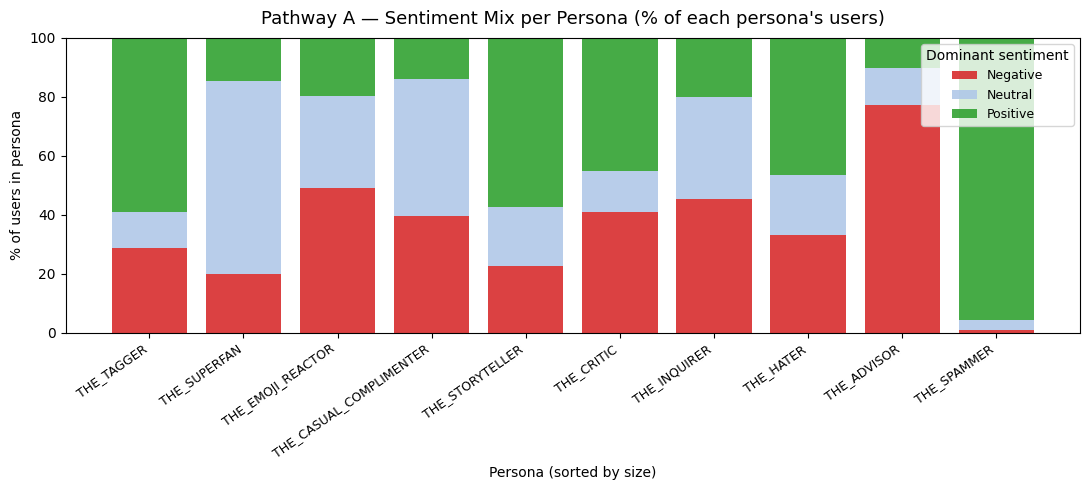

saved pa_persona_sentiment_mix.png


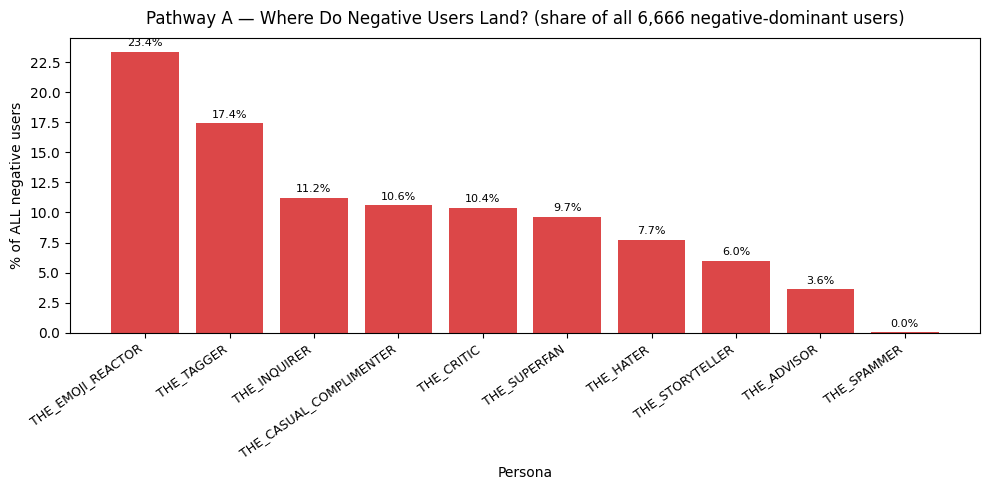

saved pa_persona_negative_dist.png


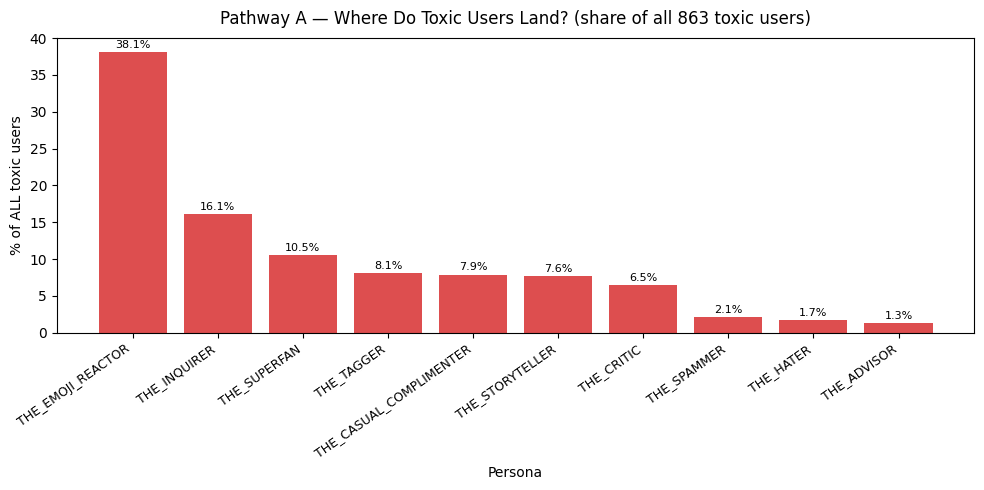

saved pa_persona_toxic_dist.png


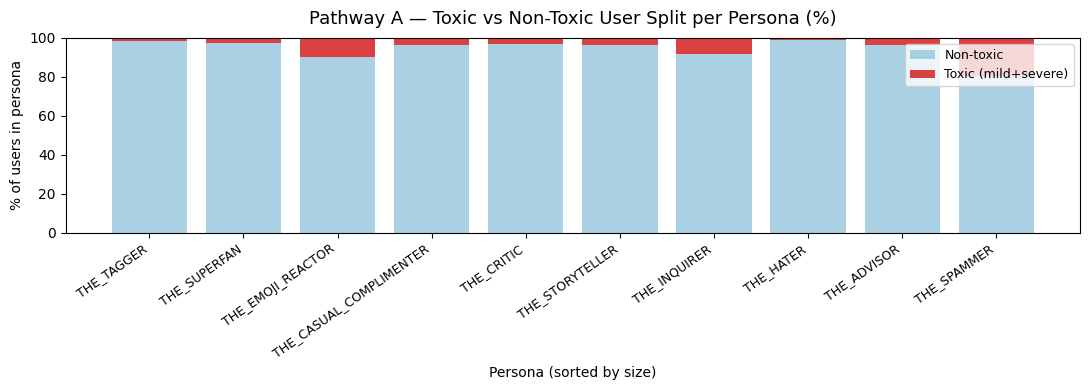

saved pa_persona_toxic_split.png

Persona  |  total  |  neg%  |  pos%  |  toxic% (of persona)  |  toxic% (of all toxic)
--------------------------------------------------------------------------------
  THE_TAGGER                        4034   28.8%   59.0%     1.7%                   8.1%
  THE_SUPERFAN                      3239   19.9%   14.6%     2.7%                  10.5%
  THE_EMOJI_REACTOR                 3163   49.2%   19.6%    10.0%                  38.1%
  THE_CASUAL_COMPLIMENTER           1781   39.7%   13.9%     3.7%                   7.9%
  THE_STORYTELLER                   1747   22.8%   57.4%     3.8%                   7.6%
  THE_CRITIC                        1693   41.0%   45.2%     3.2%                   6.5%
  THE_INQUIRER                      1652   45.3%   20.1%     8.2%                  16.1%
  THE_HATER                         1560   33.0%   46.5%     0.9%                   1.7%
  THE_ADVISOR                        311   77.2%   10.3%     3.4%                   1.3

In [83]:
# Pathway A — Persona x Sentiment & Toxicity Analysis
# Mirrors the Pathway B visualisation (pb-sentiment-persona-plots).
# Assigns Stage-1-sample users to Pathway A personas via nearest-centroid on the
# standardised feature matrix, then plots sentiment/toxicity breakdowns.
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import json, os
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ── load Pathway A taxonomy ────────────────────────────────────────────────
if not os.path.exists(TAXONOMY_A_PATH):
    raise FileNotFoundError(f"Pathway A taxonomy not found at {TAXONOMY_A_PATH} — run LLM consolidation first.")
_tax_a = json.load(open(TAXONOMY_A_PATH, encoding="utf-8"))
_tax_a_list = _tax_a.get("final_taxonomy", [])
if not _tax_a_list:
    raise ValueError("Pathway A taxonomy is empty.")
print(f"Pathway A: {len(_tax_a_list)} personas loaded.")

# ── build Stage-1 sample feature matrix (reuse pb_df if already in scope) ──
_sample_path = f"{LOCAL_DIR}/stage1_sample_users_{PLATFORM}.parquet"
if "pb_df" in dir() and len(pb_df) > 0:
    _pa_df = pb_df.copy()
    print(f"Reusing pb_df ({len(_pa_df):,} users) already in scope.")
else:
    if os.path.exists(_sample_path):
        _sample_ids = set(pd.read_parquet(_sample_path)["author_id"].astype(str))
        _pa_df = user_features[user_features["author_id"].astype(str).isin(_sample_ids)].copy()
    else:
        _pa_df = stratified_user_sample(user_features)
    _pa_df = _pa_df.reset_index(drop=True)
    print(f"Loaded/sampled {len(_pa_df):,} users for Pathway A vis.")

# Rebuild standardised feature matrix for nearest-centroid assignment.
_num_feats = SELECTED_NUMERIC_FEATURES.copy()
_num_data  = _pa_df[_num_feats].fillna(_pa_df[_num_feats].median())
_X_num     = StandardScaler().fit_transform(_num_data)
if "dominant_room_vibe" in _pa_df.columns and _pa_df["dominant_room_vibe"].nunique() > 1:
    _ohe    = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    _X_vibe = _ohe.fit_transform(_pa_df[["dominant_room_vibe"]])
    _X_pa   = np.hstack([_X_num, _X_vibe])
else:
    _X_pa = _X_num

# ── nearest-centroid assignment ──────────────────────────────────────────────
# KMeans with n_clusters = len(_tax_a_list) as a geometric split of the sample.
# Largest KMeans cluster -> most important Pathway A persona (by order in _tax_a_list).
from sklearn.cluster import KMeans

_n_pa    = len(_tax_a_list)
_km      = KMeans(n_clusters=_n_pa, random_state=42, n_init=10)
_km_labs = _km.fit_predict(_X_pa)

_km_sizes      = pd.Series(_km_labs).value_counts().sort_values(ascending=False)
_km_to_persona = {int(km_idx): _tax_a_list[pa_idx]["codename"]
                  for pa_idx, km_idx in enumerate(_km_sizes.index)
                  if pa_idx < _n_pa}

_pa_df = _pa_df.copy()
_pa_df["persona"] = pd.Series(_km_labs).map(_km_to_persona).fillna("UNKNOWN").values
print(f"Assigned {len(_pa_df):,} users to {_n_pa} Pathway A personas via nearest-centroid.")
print(_pa_df["persona"].value_counts().to_string())

# Save assignments for downstream use / re-run.
_pa_assign_path = f"{LOCAL_DIR}/pathway_a_assignments_{PLATFORM}.parquet"
_pa_df[["author_id", "persona"]].to_parquet(_pa_assign_path, index=False)
print(f"\nAssignments saved -> {_pa_assign_path}")

# ── load sentiment data ──────────────────────────────────────────────────────
_sent_raw = pd.read_parquet(SENTIMENT_PATH)
if "author_id" not in _sent_raw.columns:
    raise ValueError("sentiment parquet lacks author_id")
_sent_raw["author_id"] = _sent_raw["author_id"].astype(str)
if "sentiment" in _sent_raw.columns:
    _sent_raw["sentiment"] = canon_sentiment(_sent_raw["sentiment"])

_dom_sent = (_sent_raw.groupby("author_id")["sentiment"]
              .agg(lambda x: x.value_counts().idxmax())
              .reset_index()
              .rename(columns={"sentiment": "dominant_sentiment"}))

_has_tox = "toxicity" in _sent_raw.columns
if _has_tox:
    _dom_tox = (_sent_raw.groupby("author_id")["toxicity"]
                .agg(lambda x: x.value_counts().idxmax())
                .reset_index()
                .rename(columns={"toxicity": "dominant_toxicity"}))
    _user_any_tox = (_sent_raw.assign(
        _tox_flag=_sent_raw["toxicity"].isin(["mild", "severe"])
    ).groupby("author_id")["_tox_flag"].any()
     .reset_index().rename(columns={"_tox_flag": "is_toxic_user"}))

_df = _pa_df.merge(_dom_sent, on="author_id", how="left")
if _has_tox:
    _df = _df.merge(_dom_tox, on="author_id", how="left")
    _df = _df.merge(_user_any_tox, on="author_id", how="left")
    _df["is_toxic_user"] = _df["is_toxic_user"].fillna(False)
else:
    _df["dominant_toxicity"] = "unknown"
    _df["is_toxic_user"] = False

os.makedirs(f"{LOCAL_DIR}/figs", exist_ok=True)

SENT_ORDER  = ["negative", "neutral", "positive"]
SENT_COLORS = {"negative": "#d62728", "neutral": "#aec7e8", "positive": "#2ca02c"}
TOX_COLORS  = {"none": "#9ecae1", "mild": "#fdae6b", "severe": "#d62728", "spam_promo": "#756bb1"}

# ── compute sentiment cross-tab ───────────────────────────────────────────────
_ct_sent = (_df.dropna(subset=["dominant_sentiment"])
            .groupby(["persona", "dominant_sentiment"])
            .size().unstack(fill_value=0)
            .reindex(columns=[c for c in SENT_ORDER
                              if c in _df["dominant_sentiment"].dropna().unique()],
                     fill_value=0))
_pct_sent = _ct_sent.div(_ct_sent.sum(axis=1), axis=0) * 100
_pct_sent = _pct_sent.loc[_ct_sent.sum(axis=1).sort_values(ascending=False).index]

# ── persona descriptions ─────────────────────────────────────────────────────
_tax_by_code = {p["codename"]: p for p in _tax_a_list}
print("=" * 60)
print("PATHWAY A PERSONA DESCRIPTIONS")
print("=" * 60)
for _persona_name in _pct_sent.index:
    _p    = _tax_by_code.get(_persona_name, {})
    _lbl  = _p.get("label", "")
    _desc = _p.get("description", "No description available.")
    print(f"\n{_persona_name}" + (f" — {_lbl}" if _lbl else ""))
    print(f"  {_desc}")
print("\n" + "=" * 60 + "\n")

# ── figure 1: stacked 100% bar — sentiment mix per persona ────────────────
fig1, ax1 = plt.subplots(figsize=(11, 5))
bottom = pd.Series(0.0, index=_pct_sent.index)
for sent in [c for c in SENT_ORDER if c in _pct_sent.columns]:
    ax1.bar(_pct_sent.index, _pct_sent[sent], bottom=bottom,
            label=sent.capitalize(), color=SENT_COLORS[sent], alpha=0.88)
    bottom += _pct_sent[sent]
ax1.set_title("Pathway A — Sentiment Mix per Persona (% of each persona's users)", fontsize=13, pad=10)
ax1.set_xlabel("Persona (sorted by size)")
ax1.set_ylabel("% of users in persona")
ax1.set_ylim(0, 100)
ax1.legend(title="Dominant sentiment", loc="upper right", fontsize=9)
plt.xticks(rotation=35, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig(f"{LOCAL_DIR}/figs/pa_persona_sentiment_mix.png", dpi=150)
plt.show()
print("saved pa_persona_sentiment_mix.png")

# ── figure 2: where do ALL negative users land? ──────────────────────────────
_neg_users = _df[_df["dominant_sentiment"] == "negative"]
_total_neg = max(len(_neg_users), 1)
_neg_dist  = _neg_users.groupby("persona").size().sort_values(ascending=False)
_neg_pct   = (_neg_dist / _total_neg * 100)

fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.bar(_neg_pct.index, _neg_pct.values, color=SENT_COLORS["negative"], alpha=0.85)
ax2.set_title(
    f"Pathway A — Where Do Negative Users Land? (share of all {_total_neg:,} negative-dominant users)",
    fontsize=12, pad=10)
ax2.set_xlabel("Persona")
ax2.set_ylabel("% of ALL negative users")
ax2.yaxis.set_major_locator(mticker.MaxNLocator(integer=False))
for bar, pct in zip(ax2.patches, _neg_pct.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{pct:.1f}%", ha="center", va="bottom", fontsize=8)
plt.xticks(rotation=35, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig(f"{LOCAL_DIR}/figs/pa_persona_negative_dist.png", dpi=150)
plt.show()
print("saved pa_persona_negative_dist.png")

# ── figures 3-5: toxicity charts ──────────────────────────────────────────────
if _has_tox:
    _tox_users = _df[_df["is_toxic_user"] == True]
    _total_tox = max(len(_tox_users), 1)
    _tox_dist  = _tox_users.groupby("persona").size().sort_values(ascending=False)
    _tox_pct   = _tox_dist / _total_tox * 100

    fig4, ax4 = plt.subplots(figsize=(10, 5))
    bars = ax4.bar(_tox_pct.index, _tox_pct.values, color="#d62728", alpha=0.82)
    ax4.set_title(
        f"Pathway A — Where Do Toxic Users Land? (share of all {_total_tox:,} toxic users)",
        fontsize=12, pad=10)
    ax4.set_xlabel("Persona")
    ax4.set_ylabel("% of ALL toxic users")
    for bar, pct in zip(bars, _tox_pct.values):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{pct:.1f}%", ha="center", va="bottom", fontsize=8)
    plt.xticks(rotation=35, ha="right", fontsize=9)
    plt.tight_layout()
    plt.savefig(f"{LOCAL_DIR}/figs/pa_persona_toxic_dist.png", dpi=150)
    plt.show()
    print("saved pa_persona_toxic_dist.png")

    _tox_ct = (_df.groupby("persona")["is_toxic_user"]
               .value_counts().unstack(fill_value=0)
               .rename(columns={True: "toxic", False: "non-toxic"})
               .reindex(columns=["non-toxic", "toxic"], fill_value=0))
    _tox_ct_pct = _tox_ct.div(_tox_ct.sum(axis=1), axis=0) * 100
    _tox_ct_pct = _tox_ct_pct.loc[_tox_ct.sum(axis=1).sort_values(ascending=False).index]

    fig5, ax5 = plt.subplots(figsize=(11, 4))
    ax5.bar(_tox_ct_pct.index, _tox_ct_pct.get("non-toxic", 0),
            label="Non-toxic", color="#9ecae1", alpha=0.88)
    ax5.bar(_tox_ct_pct.index, _tox_ct_pct.get("toxic", 0),
            bottom=_tox_ct_pct.get("non-toxic", 0),
            label="Toxic (mild+severe)", color="#d62728", alpha=0.88)
    ax5.set_title("Pathway A — Toxic vs Non-Toxic User Split per Persona (%)", fontsize=13, pad=10)
    ax5.set_xlabel("Persona (sorted by size)")
    ax5.set_ylabel("% of users in persona")
    ax5.set_ylim(0, 100)
    ax5.legend(loc="upper right", fontsize=9)
    plt.xticks(rotation=35, ha="right", fontsize=9)
    plt.tight_layout()
    plt.savefig(f"{LOCAL_DIR}/figs/pa_persona_toxic_split.png", dpi=150)
    plt.show()
    print("saved pa_persona_toxic_split.png")
else:
    print("No toxicity column found — skipping toxicity charts.")

# ── summary table ─────────────────────────────────────────────────────────────
print(f"\nPersona  |  total  |  neg%  |  pos%  |  toxic% (of persona)  |  toxic% (of all toxic)")
print("-" * 80)
_total_tox_all = max(int(_df["is_toxic_user"].sum()), 1) if _has_tox else 1
for p in _pct_sent.index:
    total        = int(_ct_sent.loc[p].sum())
    neg_pct      = _pct_sent.loc[p].get("negative", 0)
    pos_pct      = _pct_sent.loc[p].get("positive", 0)
    if _has_tox and p in _tox_ct.index:
        tox_internal = float(_tox_ct.loc[p].get("toxic", 0) / max(_tox_ct.loc[p].sum(), 1) * 100)
        tox_share    = float(_tox_ct.loc[p].get("toxic", 0) / _total_tox_all * 100)
    else:
        tox_internal = tox_share = 0.0
    print(f"  {p:<32s} {total:5d}  {neg_pct:5.1f}%  {pos_pct:5.1f}%  "
          f"{tox_internal:6.1f}%                {tox_share:6.1f}%")


## Pathway B — UMAP + HDBSCAN Clustering -> Taxonomy (alternative to LLM Consolidation)

This is an **alternative** to the LLM-consolidation cell above. Run **EITHER** Pathway A
(`llm_consolidate_taxonomy`) **OR** this block — not both. Pathway B clusters the **same
stratified Stage-1 sample** by behaviour (UMAP + HDBSCAN), asks Gemini to name each cluster,
and writes the result to `taxonomy.json -> final_taxonomy` in the **identical 5-key schema**
Stage 2 consumes. Set `CONSOLIDATION_PATHWAY = "B_CLUSTER"` so the Pathway-A wrapper cell
does not overwrite this taxonomy. Then review and set `status="APPROVED"`.

In [13]:
# Pathway B dependencies (run once)
!pip install -q umap-learn hdbscan scikit-learn


In [54]:
# Pathway B config — UMAP + HDBSCAN knobs (tuned for the smaller Stage-1 sample).
# Names match the legacy Stage 3 config; harmless if that block runs later (just re-set).
UMAP_N_NEIGHBORS          = 30
UMAP_MIN_DIST             = 0.0
UMAP_N_COMPONENTS_CLUSTER = 8
UMAP_METRIC               = "euclidean"
UMAP_RANDOM_STATE         = 42

HDBSCAN_MIN_SAMPLES       = 5
HDBSCAN_CLUSTER_SELECTION = "eom"
HDBSCAN_CLUSTER_EPSILON   = 0.0

MODEL_STAGE3_NAMING          = "gemini-2.5-flash-lite"
MAX_SAMPLE_USERS_PER_CLUSTER = 50
PATHWAY_B_TARGET_CLUSTERS = TARGET_PERSONAS
CLUSTER_PERSONA_MAP_PATH   = f"{LOCAL_DIR}/cluster_persona_map_{PLATFORM}.json"
print("Pathway B config loaded (target ~", PATHWAY_B_TARGET_CLUSTERS, "clusters).")

Pathway B config loaded (target ~ 12 clusters).


In [55]:
# Re-root the clustering on the STRATIFIED STAGE-1 SAMPLE users (NOT Stage 2 output).
import os, pandas as pd, numpy as np

_sample_path = f"{LOCAL_DIR}/stage1_sample_users_{PLATFORM}.parquet"
if os.path.exists(_sample_path):
    _sample_ids = set(pd.read_parquet(_sample_path)["author_id"].astype(str))
    pb_df = user_features[user_features["author_id"].astype(str).isin(_sample_ids)].copy()
    print(f"Loaded Stage-1 sample users from {_sample_path}")
else:
    print("⚠️  stage1 sample file missing — drawing a fresh stratified sample live.")
    pb_df = stratified_user_sample(user_features)
pb_df = pb_df.reset_index(drop=True)
print(f"Pathway B working set: {len(pb_df):,} users (the Stage-1 stratified sample).")


Loaded Stage-1 sample users from outputs/stage1_persona/stage1_sample_users_instagram.parquet
Pathway B working set: 19,998 users (the Stage-1 stratified sample).


In [56]:
# Feature matrix: standardised numeric features + OHE dominant_room_vibe.
# (No persona_codename OHE — Stage 2 labels don't exist yet; this BUILDS the taxonomy.)
from sklearn.preprocessing import StandardScaler, OneHotEncoder

NUMERIC_FEATURES = SELECTED_NUMERIC_FEATURES.copy()
print(f"Numeric features ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")

num_data = pb_df[NUMERIC_FEATURES].fillna(pb_df[NUMERIC_FEATURES].median())
X_num = StandardScaler().fit_transform(num_data)

if "dominant_room_vibe" in pb_df.columns and pb_df["dominant_room_vibe"].nunique() > 1:
    ohe_vibe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    X_vibe = ohe_vibe.fit_transform(pb_df[["dominant_room_vibe"]])
    print(f"OHE dominant_room_vibe dims: {X_vibe.shape[1]} -> {ohe_vibe.categories_[0].tolist()}")
    X = np.hstack([X_num, X_vibe])
else:
    print("dominant_room_vibe: single value or absent — numeric-only matrix.")
    X = X_num
print(f"✅ Pathway B feature matrix: {X.shape}  (rows=sample users, cols=numeric+OHE)")


Numeric features (13): ['total_comments', 'activity_span_days', 'reply_ratio', 'pct_comments_under_1h', 'mean_word_count', 'mean_mention_count', 'emoji_usage_rate', 'question_rate', 'exclamation_rate', 'post_concentration_ratio', 'mean_sentiment_score', 'pct_negative', 'toxicity_rate']
dominant_room_vibe: single value or absent — numeric-only matrix.
✅ Pathway B feature matrix: (19998, 13)  (rows=sample users, cols=numeric+OHE)


In [57]:
# UMAP -> 15-D embedding for HDBSCAN.
import umap

print(f"Running UMAP ({UMAP_N_COMPONENTS_CLUSTER}-D) on {len(X):,} sample users ...")
reducer_cluster = umap.UMAP(
    n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    n_components=UMAP_N_COMPONENTS_CLUSTER,
    metric=UMAP_METRIC,
    random_state=UMAP_RANDOM_STATE,
    low_memory=True,
    verbose=True,
)
X_umap_cluster = reducer_cluster.fit_transform(X)
print(f"✅ UMAP embedding: {X_umap_cluster.shape}")


Running UMAP (8-D) on 19,998 sample users ...
UMAP(min_dist=0.0, n_components=8, n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Fri Jun 12 19:41:11 2026 Construct fuzzy simplicial set
Fri Jun 12 19:41:11 2026 Finding Nearest Neighbors
Fri Jun 12 19:41:11 2026 Building RP forest with 12 trees
Fri Jun 12 19:41:11 2026 NN descent for 14 iterations


d:\conda_envs\ma_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


	 1  /  14
	 2  /  14
	Stopping threshold met -- exiting after 2 iterations
Fri Jun 12 19:41:12 2026 Finished Nearest Neighbor Search
Fri Jun 12 19:41:12 2026 Construct embedding


Epochs completed:   2%| ▏          4/200 [00:00]

	completed  0  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  91%| █████████  182/200 [00:28]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:30]

Fri Jun 12 19:41:53 2026 Finished embedding
✅ UMAP embedding: (19998, 8)


In [58]:
# HDBSCAN auto-tuned toward PATHWAY_B_TARGET_CLUSTERS (soft <= 12).
import hdbscan, numpy as np

def cluster_near_target(emb, target=PATHWAY_B_TARGET_CLUSTERS):
    # Sweep from fine to coarse; keep candidate closest to target cluster count.
    # Prefer lower noise: among equally-close solutions pick the one with less noise.
    best = None
    for frac in (0.003, 0.005, 0.008, 0.01, 0.015, 0.02, 0.03, 0.05):
        mcs = max(3, int(len(emb) * frac))
        lab = hdbscan.HDBSCAN(
            min_cluster_size=mcs,
            min_samples=HDBSCAN_MIN_SAMPLES,
            cluster_selection_method=HDBSCAN_CLUSTER_SELECTION,
            cluster_selection_epsilon=HDBSCAN_CLUSTER_EPSILON,
        ).fit_predict(emb)
        k = len(set(lab[lab >= 0]))
        noise_pct = (lab == -1).mean()
        if best is None:
            best = (mcs, k, lab, noise_pct)
        else:
            # primary: closest to target; secondary: less noise
            if abs(k - target) < abs(best[1] - target):
                best = (mcs, k, lab, noise_pct)
            elif abs(k - target) == abs(best[1] - target) and noise_pct < best[3]:
                best = (mcs, k, lab, noise_pct)
    return best

pb_mcs, pb_k, pb_labels, pb_noise_pct = cluster_near_target(X_umap_cluster)
pb_df["macro_cluster"] = pb_labels
pb_unique_clusters = sorted(set(pb_labels[pb_labels >= 0]))
pb_n_noise = int((pb_labels == -1).sum())
print(f"Pathway B: min_cluster_size={pb_mcs} -> {pb_k} clusters | "
      f"noise={pb_n_noise:,} ({100*pb_n_noise/len(pb_labels):.1f}%)")
for c in pb_unique_clusters:
    cnt = int((pb_labels == c).sum())
    print(f"   Cluster {c:>2}: {cnt:>6,} users ({100*cnt/len(pb_labels):.1f}%)")
# Include noise as a named class so summaries and LLM see it.
if pb_n_noise > 0:
    pb_unique_clusters_with_noise = [-1] + pb_unique_clusters
    print(f"   Cluster -1 (NOISE): {pb_n_noise:>6,} users ({100*pb_n_noise/len(pb_labels):.1f}%)")
else:
    pb_unique_clusters_with_noise = pb_unique_clusters


Pathway B: min_cluster_size=299 -> 13 clusters | noise=8,542 (42.7%)
   Cluster  0:    423 users (2.1%)
   Cluster  1:    857 users (4.3%)
   Cluster  2:    307 users (1.5%)
   Cluster  3:    491 users (2.5%)
   Cluster  4:    302 users (1.5%)
   Cluster  5:    398 users (2.0%)
   Cluster  6:    749 users (3.7%)
   Cluster  7:    300 users (1.5%)
   Cluster  8:    364 users (1.8%)
   Cluster  9:    393 users (2.0%)
   Cluster 10:    959 users (4.8%)
   Cluster 11:    336 users (1.7%)
   Cluster 12:  5,577 users (27.9%)
   Cluster -1 (NOISE):  8,542 users (42.7%)


In [59]:
# 3-D UMAP visualisation of Pathway B clusters.
# Reduces the 15-D clustering embedding to 3 dimensions for scatter plotting.
import umap, numpy as np, pandas as pd
import plotly.express as px

print("Running 3-D UMAP for visualisation ...")
reducer_viz3 = umap.UMAP(
    n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=0.1,
    n_components=3,
    metric=UMAP_METRIC,
    random_state=UMAP_RANDOM_STATE,
    low_memory=True,
    verbose=False,
)
X_umap3 = reducer_viz3.fit_transform(X_umap_cluster)

viz_df = pd.DataFrame({
    "x": X_umap3[:, 0],
    "y": X_umap3[:, 1],
    "z": X_umap3[:, 2],
    "cluster": pb_labels.astype(str),
    "is_noise": pb_labels == -1,
})
# Label noise distinctly so it stands out in the legend.
viz_df["cluster_label"] = viz_df["cluster"].apply(
    lambda c: "NOISE" if c == "-1" else f"Cluster {c}"
)

# Colour map: noise is grey, real clusters get distinct colours.
unique_labels = sorted(viz_df["cluster_label"].unique(), key=lambda x: (x == "NOISE", x))
color_map = {}
palette = px.colors.qualitative.Bold + px.colors.qualitative.Pastel
ci = 0
for lbl in unique_labels:
    if lbl == "NOISE":
        color_map[lbl] = "#aaaaaa"
    else:
        color_map[lbl] = palette[ci % len(palette)]
        ci += 1

fig = px.scatter_3d(
    viz_df, x="x", y="y", z="z",
    color="cluster_label",
    color_discrete_map=color_map,
    opacity=0.5,
    size_max=3,
    title=f"Pathway B — UMAP 3-D ({pb_k} clusters + noise)",
    labels={"x": "UMAP-1", "y": "UMAP-2", "z": "UMAP-3", "cluster_label": "Cluster"},
    category_orders={"cluster_label": unique_labels},
)
fig.update_traces(marker=dict(size=2))
fig.update_layout(legend=dict(itemsizing="constant"), margin=dict(l=0, r=0, t=40, b=0))
fig.show()

# Cluster size bar chart.
size_df = (
    viz_df.groupby("cluster_label", observed=True)
    .size().reset_index(name="n_users")
    .sort_values("n_users", ascending=False)
)
fig2 = px.bar(
    size_df, x="cluster_label", y="n_users",
    color="cluster_label",
    color_discrete_map=color_map,
    title="Cluster sizes (Pathway B)",
    labels={"cluster_label": "Cluster", "n_users": "Users"},
    category_orders={"cluster_label": unique_labels},
)
fig2.update_layout(showlegend=False)
fig2.show()


Running 3-D UMAP for visualisation ...


d:\conda_envs\ma_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
d:\conda_envs\ma_env\lib\site-packages\sklearn\manifold\_spectral_embedding.py:453: UserWarning: Exited at iteration 63 with accuracies 
[1.05547498e-12 1.32350566e-05 1.53194225e-05 2.98420644e-05
 2.38109041e-06]
not reaching the requested tolerance 3.129243850708008e-06.
Use iteration 52 instead with accuracy 
6.818925185528225e-06.

  _, diffusion_map = lobpcg(
d:\conda_envs\ma_env\lib\site-packages\sklearn\manifold\_spectral_embedding.py:453: UserWarning: Exited postprocessing with accuracies 
[5.46572390e-14 1.09937470e-05 5.19688267e-06 2.58981318e-06
 1.53141818e-05]
not reaching the requested tolerance 3.129243850708008e-06.
  _, diffusion_map = lobpcg(


In [61]:
# Per-cluster summary (behaviour + room-vibe mix + sample comments) for LLM naming.
# cluster_id == -1 is the HDBSCAN noise class.

# Build once: per-user dominant comment sentiment, used to stratify which users we show the LLM.
_USER_DOM_SENT = None
try:
    if os.path.exists(SENTIMENT_PATH):
        _su = pd.read_parquet(SENTIMENT_PATH)
        if "author_id" not in _su.columns and "comment_id" in _su.columns:
            _su = _su.merge(ig_comments[["comment_id", "author_id"]], on="comment_id", how="left")
        if {"author_id", "sentiment"}.issubset(_su.columns):
            _su["author_id"] = _su["author_id"].astype(str)
            _su["sentiment"] = canon_sentiment(_su["sentiment"])
            _USER_DOM_SENT = (_su.dropna(subset=["author_id"])
                                 .groupby("author_id")["sentiment"]
                                 .agg(lambda x: x.value_counts().idxmax())
                                 .reset_index()
                                 .rename(columns={"sentiment": "dominant_sentiment"}))
            print(f"[pb-summaries] per-user dominant sentiment cached for {len(_USER_DOM_SENT):,} users; "
                  f"mix = {_USER_DOM_SENT['dominant_sentiment'].value_counts(normalize=True).mul(100).round(1).to_dict()}")
except Exception as _e:
    print(f"[pb-summaries] could not build sentiment cache ({_e}); falling back to random user pick.")

def build_cluster_summary_b(cluster_id, df):
    sub = df[df["macro_cluster"] == cluster_id]
    n = len(sub)
    stat_cols = [c for c in [
        "total_comments", "activity_span_days", "mean_hours_to_comment",
        "pct_comments_under_1h", "reply_ratio", "mean_word_count",
        "emoji_usage_rate", "question_rate", "exclamation_rate",
        # sentiment/toxicity signals — surfaced so the LLM can flag hostile/negative clusters
        "mean_sentiment_score", "pct_negative", "toxicity_rate",
    ] if c in sub.columns]
    mean_stats = sub[stat_cols].mean().round(3).to_dict()

    vibe_mix = {}
    if "dominant_room_vibe" in sub.columns:
        vibe_mix = (sub["dominant_room_vibe"].value_counts(normalize=True)
                    .mul(100).round(1).head(5).to_dict())

    # Pick N_USERS_FOR_LLM representative users, STRATIFIED by each user's dominant sentiment,
    # so every cluster contributes its positive/neutral/negative voices (not 5 random users that
    # would almost always be positive). Include ALL stored comments per picked user.
    N_USERS_FOR_LLM = 12
    sample_users = []
    if "top_comments_sample" in sub.columns:
        picks_pool = sub[["author_id", "top_comments_sample"]].dropna(subset=["top_comments_sample"]).copy()
        # attach per-user dominant sentiment (module-level cache built once: _USER_DOM_SENT)
        if "_USER_DOM_SENT" in globals() and len(picks_pool):
            picks_pool = picks_pool.merge(_USER_DOM_SENT, on="author_id", how="left")
            picks_pool["dominant_sentiment"] = picks_pool["dominant_sentiment"].fillna("neutral")
        else:
            picks_pool["dominant_sentiment"] = "neutral"

        if len(picks_pool):
            # proportional allocation across sentiment strata, but guarantee >=1 from any
            # non-empty minority stratum (esp. negative) when the cluster has room.
            strata = list(picks_pool.groupby("dominant_sentiment"))
            picked_frames = []
            remaining = N_USERS_FOR_LLM
            # first pass: 1 guaranteed seat per non-empty stratum
            for cat, grp in strata:
                if remaining <= 0:
                    break
                picked_frames.append(grp.sample(n=1, random_state=42))
                remaining -= 1
            # second pass: fill the rest proportionally to stratum size
            if remaining > 0:
                already = set(pd.concat(picked_frames)["author_id"]) if picked_frames else set()
                rest_pool = picks_pool[~picks_pool["author_id"].isin(already)]
                if len(rest_pool):
                    take = min(remaining, len(rest_pool))
                    picked_frames.append(
                        rest_pool.groupby("dominant_sentiment", group_keys=False)
                                 .apply(lambda g: g.sample(
                                     n=max(1, round(take * len(g) / len(rest_pool))),
                                     random_state=42), include_groups=False)
                                 .head(take))
            picks = pd.concat(picked_frames).drop_duplicates("author_id").head(N_USERS_FOR_LLM)
        else:
            picks = picks_pool

        for _, row in picks.iterrows():
            all_comments = [c.strip() for c in str(row["top_comments_sample"]).split("|||") if c.strip()]
            sample_users.append({
                "user_id": str(row["author_id"]),
                "dominant_sentiment": str(row.get("dominant_sentiment", "neutral")),
                "comments": all_comments,
            })
    # pct_audience is relative to ALL users (incl. noise) so noise share is meaningful.
    return {
        "cluster_id": int(cluster_id),
        "is_noise": cluster_id == -1,
        "n_users": n,
        "pct_audience": round(100 * n / max(len(df), 1), 1),
        "mean_behavioral_stats": mean_stats,
        "dominant_room_vibe_mix": vibe_mix,
        "sample_users": sample_users,
    }

pb_cluster_summaries = [build_cluster_summary_b(c, pb_df) for c in pb_unique_clusters_with_noise]
print(f"Built summaries for {len(pb_cluster_summaries)} clusters (incl. noise):")
for s in pb_cluster_summaries:
    tag = " [NOISE]" if s["is_noise"] else ""
    print(f"   Cluster {s['cluster_id']:>2}{tag}  n={s['n_users']:>6,} ({s['pct_audience']:.1f}%)  "
          f"vibe={list(s['dominant_room_vibe_mix'].items())[:2]}")


[pb-summaries] per-user dominant sentiment cached for 191,096 users; mix = {'positive': 80.4, 'neutral': 15.0, 'negative': 4.6}
Built summaries for 14 clusters (incl. noise):
   Cluster -1 [NOISE]  n= 8,542 (42.7%)  vibe=[('neutral', 100.0)]
   Cluster  0  n=   423 (2.1%)  vibe=[('neutral', 100.0)]
   Cluster  1  n=   857 (4.3%)  vibe=[('neutral', 100.0)]
   Cluster  2  n=   307 (1.5%)  vibe=[('neutral', 100.0)]
   Cluster  3  n=   491 (2.5%)  vibe=[('neutral', 100.0)]
   Cluster  4  n=   302 (1.5%)  vibe=[('neutral', 100.0)]
   Cluster  5  n=   398 (2.0%)  vibe=[('neutral', 100.0)]
   Cluster  6  n=   749 (3.7%)  vibe=[('neutral', 100.0)]
   Cluster  7  n=   300 (1.5%)  vibe=[('neutral', 100.0)]
   Cluster  8  n=   364 (1.8%)  vibe=[('neutral', 100.0)]
   Cluster  9  n=   393 (2.0%)  vibe=[('neutral', 100.0)]
   Cluster 10  n=   959 (4.8%)  vibe=[('neutral', 100.0)]
   Cluster 11  n=   336 (1.7%)  vibe=[('neutral', 100.0)]
   Cluster 12  n= 5,577 (27.9%)  vibe=[('neutral', 100.0)]


In [62]:
# LLM-label each cluster into a 6-key persona schema (noise included, flagged).
from google.genai import types

_real_summaries  = [s for s in pb_cluster_summaries if not s["is_noise"]]
_noise_summary   = next((s for s in pb_cluster_summaries if s["is_noise"]), None)
# All summaries go to LLM — noise is clearly flagged in the block text.
_all_for_llm     = ([_noise_summary] if _noise_summary else []) + _real_summaries

PB_NAMING_SYSTEM = (
    "You are a strategic audience analyst for an Italian Instagram influencer agency.\n"
    "Commenters were clustered into behavioural macro-segments (UMAP + HDBSCAN). Each cluster is\n"
    "described by mean behavioural stats, a dominant room-vibe mix, and representative comments.\n"
    "\n"
    "NOISE CLUSTER: one cluster is labelled *** NOISE ***. These are HDBSCAN noise points —\n"
    "users too behaviourally scattered to fit any dense cluster. Do NOT simply call them\n"
    "NOISE_UNCLASSIFIED. Instead, examine their stats and comments carefully and give them a\n"
    "descriptive label that captures their dominant observable characteristics (e.g. erratic\n"
    "lurkers, one-off commenters, etc.). Make clear in the description that they lack cluster\n"
    "cohesion, but still characterise what they seem to be doing.\n"
    "\n"
    "LABEL BIAS WARNING: Do NOT default to positive or neutral personas. The dataset may contain\n"
    "critics, trolls, toxic commenters, or passive lurkers. If a cluster's stats show high\n"
    "toxicity_rate, high pct_negative, low word_count, or hostile comment fragments, label it\n"
    "accordingly (e.g. CRITICAL_DETRACTOR, TOXIC_TROLL, PASSIVE_LURKER). Be honest and\n"
    "comprehensive — the full spectrum of audience behaviour must be represented.\n"
    "\n"
    "Turn every cluster into ONE audience persona. Personas must be MUTUALLY EXCLUSIVE.\n"
    f"Return exactly {len(_all_for_llm)} personas ordered by audience share (largest first).\n"
    "For each persona output exactly these 5 keys:\n"
    "  codename (UPPER_SNAKE_CASE),\n"
    "  label (short Title Case, 2-4 words),\n"
    "  description (1-2 sentences — who they are and what drives their engagement),\n"
    "  quantitative_signals (3-5 distinguishing behavioural signals as strings),\n"
    "  example_comments (2-3 verbatim fragments drawn from the cluster's sample comments),\n"
        "Output ONLY a valid JSON array of objects with exactly those 5 keys. No preamble, no markdown fences."
)

def _pb_block(s):
    stats = "  ".join(f"{k}={v:.2f}" if isinstance(v, float) else f"{k}={v}"
                      for k, v in s["mean_behavioral_stats"].items())
    vibe = "  ".join(f"{k}: {v}%" for k, v in s["dominant_room_vibe_mix"].items())
    noise_tag = "  *** NOISE — low-cohesion, no dominant pattern ***" if s["is_noise"] else ""
    users_block = ""
    for u in s.get("sample_users", []):
        comment_lines = "\n      ".join(f'"{c}"' for c in u["comments"])
        _sent = u.get("dominant_sentiment", "")
        _tag = f" [dominant sentiment: {_sent}]" if _sent else ""
        users_block += f'\n  USER {u["user_id"]}{_tag}:\n      {comment_lines}'
    return (f"CLUSTER {s['cluster_id']}{noise_tag}  (n={s['n_users']:,}, {s['pct_audience']}% of all users)\n"
            f"  Mean behavioural stats: {stats}\n"
            f"  Dominant room-vibe mix: {vibe}\n"
            f"  Representative users (full comment history):{users_block}")

pb_prompt = PB_NAMING_SYSTEM + "\n\n=== CLUSTER DATA ===\n\n" + "\n\n".join(
    _pb_block(s) for s in _all_for_llm)

pb_cfg = types.GenerateContentConfig(
    temperature=0.0, top_p=1.0, max_output_tokens=8192,
    response_mime_type="application/json",
    thinking_config=types.ThinkingConfig(thinking_budget=4096),
)
print(f"Labelling {len(_all_for_llm)} clusters via {MODEL_STAGE3_NAMING} (noise included + flagged) ...")
pb_resp = client.models.generate_content(model=MODEL_STAGE3_NAMING, contents=pb_prompt, config=pb_cfg)

_pb_text = strip_fences(pb_resp.text or "")
try:
    pb_macro_personas = json.loads(_pb_text)
except Exception as e:
    print("Could not parse LLM output:", str(e)[:120], "\n", _pb_text[:400])
    pb_macro_personas = []

_keys = ["codename", "label", "description", "quantitative_signals", "example_comments"]
pb_macro_personas = [{k: p.get(k, "" if k in ("codename","label","description") else [])
                      for k in _keys}
                     for p in pb_macro_personas if isinstance(p, dict)][:TARGET_PERSONAS]

print(f"\n{len(pb_macro_personas)} personas from Pathway B:")
for p in pb_macro_personas:
    is_noise = p["codename"] == "NOISE_UNCLASSIFIED"
    tag = " [NOISE]" if is_noise else ""
    print(f"   {str(p['codename']):<30}{tag}  | {p['label']}")

import os
# Pathway B writes its OWN file so it can be compared with Pathway A.
data = {"status": "PENDING_HUMAN_REVIEW", "pathway": "B_CLUSTER",
        "final_taxonomy": pb_macro_personas,
        "instructions": ("Pathway B (UMAP+HDBSCAN) taxonomy. Compare with Pathway A, then "
                         "promote the chosen one to taxonomy.json (status='APPROVED') before Stage 2.")}
with open(TAXONOMY_B_PATH, "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=2)
print(f"\nPathway B: saved {len(pb_macro_personas)} personas -> {TAXONOMY_B_PATH}")

# cluster_id -> codename map (covers -1 for noise).
_cluster_map = {int(s["cluster_id"]): pb_macro_personas[i]["codename"]
                for i, s in enumerate(pb_cluster_summaries) if i < len(pb_macro_personas)}
with open(CLUSTER_PERSONA_MAP_PATH, "w", encoding="utf-8") as f:
    json.dump(_cluster_map, f, ensure_ascii=False, indent=2)
pb_df[["author_id", "macro_cluster"]].to_parquet(
    f"{LOCAL_DIR}/pathway_b_assignments_{PLATFORM}.parquet", index=False)
print(f"Cluster->persona map -> {CLUSTER_PERSONA_MAP_PATH}; "
      f"assignments -> pathway_b_assignments_{PLATFORM}.parquet")


Labelling 14 clusters via gemini-2.5-flash-lite (noise included + flagged) ...

12 personas from Pathway B:
   EPHEMERAL_REACTORS              | Ephemeral Reactors
   DEDICATED_OBSERVERS             | Dedicated Observers
   NARRATIVE_COMMENTERS            | Narrative Commenters
   BRIEF_ONE_OFFS                  | Brief One-Offs
   INQUISITIVE_COMMENTERS          | Inquisitive Commenters
   QUICK_EMOJI_REACTORS            | Quick Emoji Reactors
   ENTHUSIASTIC_SHORTIES           | Enthusiastic Shorties
   DETAILED_STORYTELLERS           | Detailed Storytellers
   EXPRESSIVE_ENGAGERS             | Expressive Engagers
   CASUAL_COMMENTERS               | Casual Commenters
   INFREQUENT_MULTI_COMMENTERS     | Infrequent Multi-Commenters
   TAG_ONLY_COMMENTERS             | Tag-Only Commenters

Pathway B: saved 12 personas -> outputs/stage1_persona/taxonomy_pathwayB.json
Cluster->persona map -> outputs/stage1_persona/cluster_persona_map_instagram.json; assignments -> pathway_b_assignments_

In [64]:
# Display full persona descriptions
import json, os
from IPython.display import Markdown, display

_taxonomy = (
    _taxonomy if "_taxonomy" in dir()
    else json.load(open(TAXONOMY_JSON_PATH, encoding="utf-8")).get("final_taxonomy", [])
)

for persona in _taxonomy:
    codename = persona["codename"]
    label = persona["label"]
    description = persona["description"]
    signals = persona.get("quantitative_signals", [])
    examples = persona.get("example_comments", [])

    signals_md = "\n".join(f"- {s}" for s in signals)
    examples_md = "\n".join(f"> {e}" for e in examples)

    md = f"""
### **{codename}** — {label}

{description}

**Key signals:**  
{signals_md}

**Example comments:**  
{examples_md}

---
"""
    display(Markdown(md))



### **THE_SUPERFAN** — Superfan

A loyal and long-term follower who consistently expresses strong admiration and personal connection. Their comments are enthusiastic, descriptive, and full of positive emotion.

**Key signals:**  
- High activity span (e.g., >1000 days)
- Multiple comments on unique posts
- High positive sentiment
- Mix of descriptive text and emojis

**Example comments:**  
> Sei favolosa Cami! 😍❤️
> Sei una DEA
> Il tuo romanzo è meraviglioso.

---



### **THE_TAGGER** — The Tagger

Uses the comment section primarily to share content with friends by tagging them. The interaction is aimed at their social circle, not direct engagement with the influencer.

**Key signals:**  
- Comment consists mainly of @ mentions
- Very low word count (avg 1-3 words)
- Often a user's only comment
- High volume of comments are tags

**Example comments:**  
> @ericapacitto totalmente noi
> @panz96 @eh_se
> @alessiafaziani quello dell’escape room sembra bello

---



### **THE_REACTOR** — The Reactor

Provides immediate, low-effort emotional feedback, communicating almost exclusively through emojis or short, exclamatory phrases. Their goal is to express a quick feeling like laughter, love, or surprise.

**Key signals:**  
- Very high emoji rate (often 100%)
- Very low word count (avg 0-2 words)
- Comments immediately after post
- Zero question rate

**Example comments:**  
> 😂😂😂😂😂😂😂😂😂😂😂
> 😍😍🔝🔝
> Oddiooooo🤣🤣🤣

---



### **THE_CRITIC** — The Critic

Engages thoughtfully by offering corrections, challenging opinions, or providing nuanced feedback. Their comments are often analytical and aim to add depth or an alternative perspective to the conversation.

**Key signals:**  
- Higher average word count
- Low emoji rate
- Often provides corrections or alternative facts
- May engage in replies with others

**Example comments:**  
> Manca il sesso, 1 stella su 5.
> Nessuno le dica che Vidiciatico è in montagna e non una località marittima
> La pianta dovrebbe essere un Lauroceraso 😊

---



### **THE_INQUIRER** — The Inquirer

Asks direct questions to get information, often seeking details about products, locations, techniques, or personal aspects of the influencer's life. Their engagement is functional and goal-oriented.

**Key signals:**  
- High question rate (often 100%)
- Comments seek specific information
- Often tags the influencer directly
- Moderate word count

**Example comments:**  
> Dove hai preso i jeans? :) @camihawke
> Cosa leggi?
> Stupendo 😍 c'è anche waterproof?

---



### **THE_STORYTELLER** — The Storyteller

Shares personal anecdotes, detailed experiences, or deep reflections related to the post's theme. These high-effort comments add a personal narrative to the discussion and seek connection through shared experience.

**Key signals:**  
- Very high average word count (e.g., >25 words)
- Self-referential language ('Io che...', 'A me è successo...')
- Often a single, in-depth comment
- Low reply ratio

**Example comments:**  
> Totalmente d’accordo. Ecco perché ho figliato a quasi 42 anni. 😂 E non potevo fare scelta migliore.
> Io ho DAVVERO rotto il frullatore facendo sorbetto alla banana e sorbetto alla pesca
> Il periodo del trasloco lo ricordo come uno dei più pesanti!!

---



### **THE_CASUAL** — The Casual

An infrequent or one-time commenter who leaves short, simple observations or agreements. Their low-effort engagement indicates they are more of a lurker who occasionally surfaces.

**Key signals:**  
- Total comments: 1
- Activity span: 0 days
- Short, declarative statements
- Low emotional intensity

**Example comments:**  
> Concordo
> 6x6
> In equilibrio

---



### **THE_HATER** — The Hater

Posts aggressive, insulting, provocative, or purely negative comments. Their goal is to harass, troll, or express hostility towards the influencer or other community members.

**Key signals:**  
- High negative sentiment
- Uses aggressive or profane language
- Often makes personal attacks
- May use sarcastic emojis

**Example comments:**  
> Hai di nuovo mangiato la droga eh? 🤔
> Farai una brutta fine
> ma smettetela di idolatrarla dio cane

---



### **THE_SELF_PROMOTER** — The Self-Promoter

Uses the comment section to advertise their own account, business, or content. Comments are often generic, off-topic, and have a clear transactional purpose.

**Key signals:**  
- Includes 'follow me' or 'check my profile' language
- May contain URLs or promotional hashtags
- Often a single, copy-pasted comment
- Low relevance to the post's content

**Example comments:**  
> Seguiteci 😊
> Notizie e consigli sempre aggiornati sul mondo del sesso 🔥
> Ciao! ☺️ ti piacerebbe avere un codice sconto Yves Rocher oppure lavorare con noi? 💚

---


## Persona × Sentiment & Toxicity Analysis

These charts show how **sentiment** and **toxicity** distribute across personas:

- **Sentiment mix**: what fraction of each persona's users are negative/neutral/positive
- **Where do negative users land**: which personas capture the most negative-dominant users (% of all negatives)
- **Toxicity mix**: internal toxicity breakdown within each persona
- **Where do toxic users land**: which personas capture the most toxic users (% of all toxic users)
- **Toxic vs non-toxic split**: proportion of toxic users within each persona

NOISE_UNCLASSIFIED users are excluded from all charts.


C:\Users\alire\AppData\Local\Temp\ipykernel_27632\3245466750.py:44: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  _df["is_toxic_user"] = _df["is_toxic_user"].fillna(False)


PERSONA DESCRIPTIONS

UNKNOWN
  No description available.

TAG_ONLY_COMMENTERS
  No description available.

NARRATIVE_COMMENTERS
  No description available.

DETAILED_STORYTELLERS
  No description available.

INQUISITIVE_COMMENTERS
  No description available.

DEDICATED_OBSERVERS
  No description available.

ENTHUSIASTIC_SHORTIES
  No description available.

INFREQUENT_MULTI_COMMENTERS
  No description available.

CASUAL_COMMENTERS
  No description available.

BRIEF_ONE_OFFS
  No description available.

QUICK_EMOJI_REACTORS
  No description available.

EXPRESSIVE_ENGAGERS
  No description available.




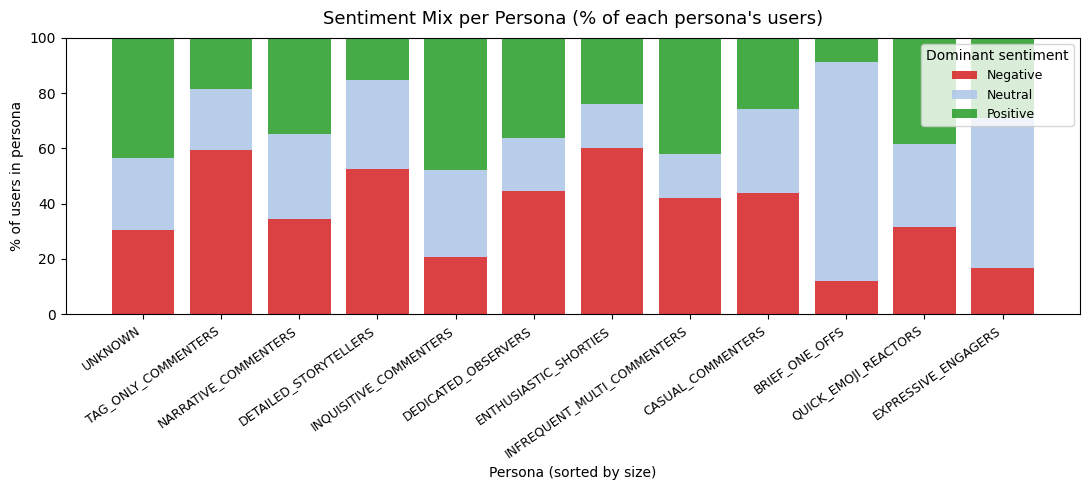

saved persona_sentiment_mix.png


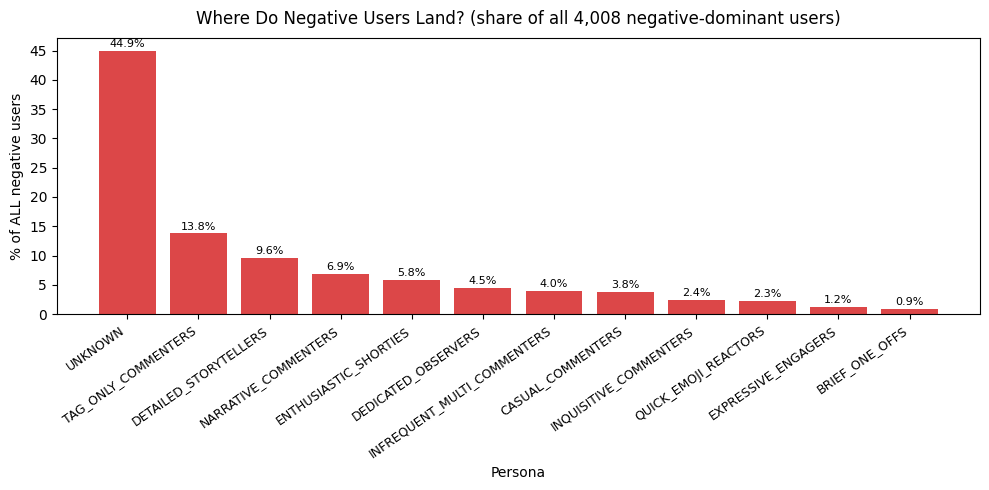

saved persona_negative_dist.png


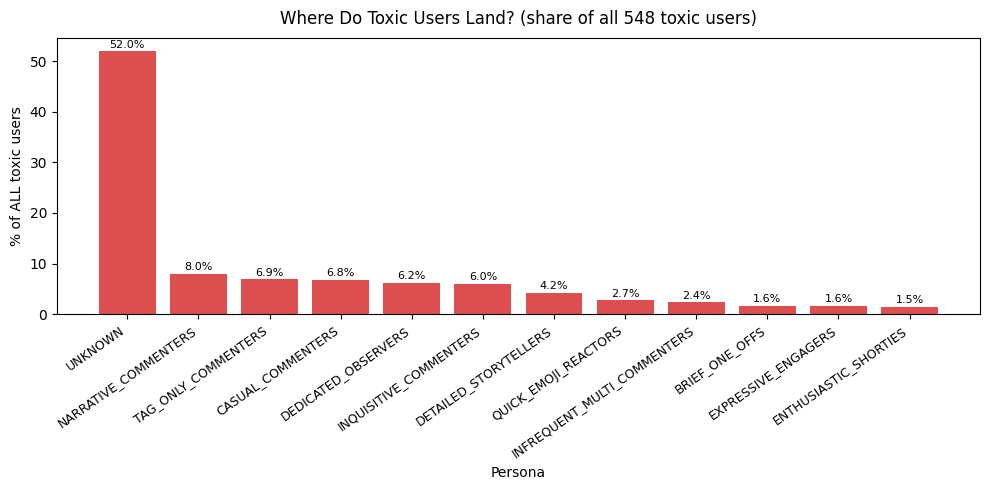

saved persona_toxic_dist.png


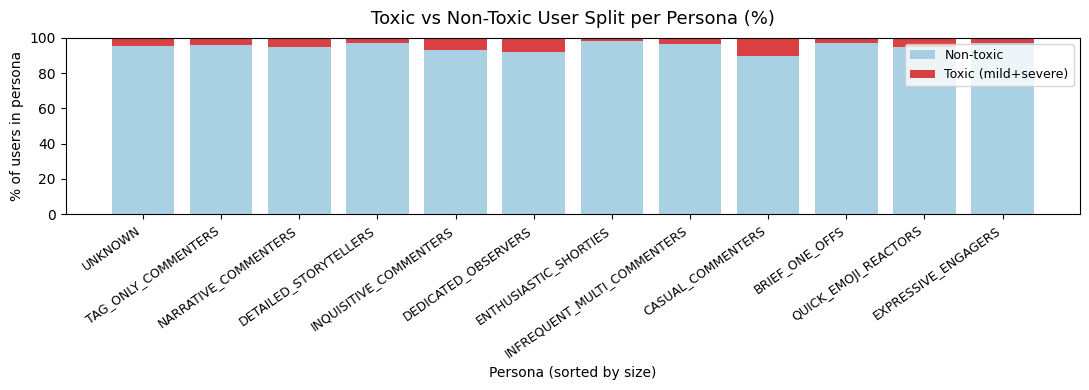

saved persona_toxic_split.png

Persona  |  total  |  neg%  |  pos%  |  toxic% (of persona)  |  toxic% (of all toxic)
--------------------------------------------------------------------------------
  UNKNOWN                           5877   30.6%   43.5%     4.8%                  52.0%
  TAG_ONLY_COMMENTERS                931   59.4%   18.6%     4.0%                   6.9%
  NARRATIVE_COMMENTERS               801   34.3%   34.7%     5.1%                   8.0%
  DETAILED_STORYTELLERS              733   52.5%   15.1%     3.1%                   4.2%
  INQUISITIVE_COMMENTERS             466   20.8%   47.9%     6.7%                   6.0%
  DEDICATED_OBSERVERS                402   44.5%   36.1%     8.0%                   6.2%
  ENTHUSIASTIC_SHORTIES              388   60.3%   24.0%     2.0%                   1.5%
  INFREQUENT_MULTI_COMMENTERS        377   42.2%   42.2%     3.3%                   2.4%
  CASUAL_COMMENTERS                  348   43.7%   25.6%    10.2%                   6.8%
 

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import json, os

# ── load data ──────────────────────────────────────────────────────────────
_pb = pd.read_parquet(f"{LOCAL_DIR}/pathway_b_assignments_{PLATFORM}.parquet")
_pb["author_id"] = _pb["author_id"].astype(str)

_sent_raw = pd.read_parquet(SENTIMENT_PATH)
if "author_id" not in _sent_raw.columns:
    raise ValueError("sentiment parquet lacks author_id — join via comment_id first")
_sent_raw["author_id"] = _sent_raw["author_id"].astype(str)
if "sentiment" in _sent_raw.columns:
    _sent_raw["sentiment"] = canon_sentiment(_sent_raw["sentiment"])

# dominant sentiment per user
_dom_sent = (_sent_raw.groupby("author_id")["sentiment"]
              .agg(lambda x: x.value_counts().idxmax())
              .reset_index()
              .rename(columns={"sentiment": "dominant_sentiment"}))

# dominant toxicity per user
_has_tox = "toxicity" in _sent_raw.columns
if _has_tox:
    _dom_tox = (_sent_raw.groupby("author_id")["toxicity"]
                .agg(lambda x: x.value_counts().idxmax())
                .reset_index()
                .rename(columns={"toxicity": "dominant_toxicity"}))
    # is_toxic_user: at least one comment flagged mild or severe
    _user_any_tox = (_sent_raw.assign(
        _tox_flag=_sent_raw["toxicity"].isin(["mild", "severe"])
    ).groupby("author_id")["_tox_flag"].any()
     .reset_index().rename(columns={"_tox_flag": "is_toxic_user"}))

_cmap = json.load(open(CLUSTER_PERSONA_MAP_PATH, encoding="utf-8"))
_cmap_int = {int(k): v for k, v in _cmap.items()}

_df = _pb.merge(_dom_sent, on="author_id", how="left")
if _has_tox:
    _df = _df.merge(_dom_tox, on="author_id", how="left")
    _df = _df.merge(_user_any_tox, on="author_id", how="left")
    _df["is_toxic_user"] = _df["is_toxic_user"].fillna(False)
else:
    _df["dominant_toxicity"] = "unknown"
    _df["is_toxic_user"] = False

_df["persona"] = _df["macro_cluster"].map(_cmap_int).fillna("UNKNOWN")
# keep NOISE in df but label it; exclude from per-persona breakdowns below
_df_all  = _df.copy()
_df_real = _df[_df["macro_cluster"] != -1].copy()

os.makedirs(f"{LOCAL_DIR}/figs", exist_ok=True)

SENT_ORDER  = ["negative", "neutral", "positive"]
SENT_COLORS = {"negative": "#d62728", "neutral": "#aec7e8", "positive": "#2ca02c"}
TOX_ORDER   = ["none", "mild", "severe", "spam_promo"]
TOX_COLORS  = {"none": "#9ecae1", "mild": "#fdae6b", "severe": "#d62728", "spam_promo": "#756bb1"}


# ── figure 1: stacked 100% bar — sentiment mix per persona ────────────────
_ct_sent = (_df_real.dropna(subset=["dominant_sentiment"])
            .groupby(["persona", "dominant_sentiment"])
            .size().unstack(fill_value=0)
            .reindex(columns=[c for c in SENT_ORDER
                              if c in _df_real["dominant_sentiment"].dropna().unique()],
                     fill_value=0))
_pct_sent = _ct_sent.div(_ct_sent.sum(axis=1), axis=0) * 100
_pct_sent = _pct_sent.loc[_ct_sent.sum(axis=1).sort_values(ascending=False).index]

# ── persona descriptions ──────────────────────────────────────────────────────
_tax_data = json.load(open(TAXONOMY_JSON_PATH, encoding="utf-8"))
_tax_list = _tax_data.get("final_taxonomy", [])
_tax_by_code = {p["codename"]: p for p in _tax_list}
print("=" * 60)
print("PERSONA DESCRIPTIONS")
print("=" * 60)
for _persona_name in _pct_sent.index:
    _p = _tax_by_code.get(_persona_name, {})
    _lbl = _p.get("label", "")
    _desc = _p.get("description", "No description available.")
    print(f"\n{_persona_name}" + (f" — {_lbl}" if _lbl else ""))
    print(f"  {_desc}")
print("\n" + "=" * 60 + "\n")

fig1, ax1 = plt.subplots(figsize=(11, 5))
bottom = pd.Series(0.0, index=_pct_sent.index)
for sent in [c for c in SENT_ORDER if c in _pct_sent.columns]:
    ax1.bar(_pct_sent.index, _pct_sent[sent], bottom=bottom,
            label=sent.capitalize(), color=SENT_COLORS[sent], alpha=0.88)
    bottom += _pct_sent[sent]
ax1.set_title("Sentiment Mix per Persona (% of each persona's users)", fontsize=13, pad=10)
ax1.set_xlabel("Persona (sorted by size)")
ax1.set_ylabel("% of users in persona")
ax1.set_ylim(0, 100)
ax1.legend(title="Dominant sentiment", loc="upper right", fontsize=9)
plt.xticks(rotation=35, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig(f"{LOCAL_DIR}/figs/persona_sentiment_mix.png", dpi=150)
plt.show()
print("saved persona_sentiment_mix.png")

# ── figure 2: where do ALL negative users land? (share of total negatives) ─
_neg_users = _df_real[_df_real["dominant_sentiment"] == "negative"]
_total_neg = max(len(_neg_users), 1)
_neg_dist  = _neg_users.groupby("persona").size().sort_values(ascending=False)
_neg_pct   = (_neg_dist / _total_neg * 100)

fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.bar(_neg_pct.index, _neg_pct.values, color=SENT_COLORS["negative"], alpha=0.85)
ax2.set_title(
    f"Where Do Negative Users Land? (share of all {_total_neg:,} negative-dominant users)",
    fontsize=12, pad=10)
ax2.set_xlabel("Persona")
ax2.set_ylabel("% of ALL negative users")
ax2.yaxis.set_major_locator(mticker.MaxNLocator(integer=False))
for bar, pct in zip(ax2.patches, _neg_pct.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{pct:.1f}%", ha="center", va="bottom", fontsize=8)
plt.xticks(rotation=35, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig(f"{LOCAL_DIR}/figs/persona_negative_dist.png", dpi=150)
plt.show()
print("saved persona_negative_dist.png")

# ── figures 3-5: toxicity charts ──────────────────────────────────────────
if _has_tox:
   

    # figure 4: where do ALL toxic users land? (share of total toxic users per persona)
    _tox_users  = _df_real[_df_real["is_toxic_user"] == True]
    _total_tox  = max(len(_tox_users), 1)
    _tox_dist   = _tox_users.groupby("persona").size().sort_values(ascending=False)
    _tox_pct    = _tox_dist / _total_tox * 100

    fig4, ax4 = plt.subplots(figsize=(10, 5))
    bars = ax4.bar(_tox_pct.index, _tox_pct.values,
                   color="#d62728", alpha=0.82)
    ax4.set_title(
        f"Where Do Toxic Users Land? (share of all {_total_tox:,} toxic users)",
        fontsize=12, pad=10)
    ax4.set_xlabel("Persona")
    ax4.set_ylabel("% of ALL toxic users")
    for bar, pct in zip(bars, _tox_pct.values):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{pct:.1f}%", ha="center", va="bottom", fontsize=8)
    plt.xticks(rotation=35, ha="right", fontsize=9)
    plt.tight_layout()
    plt.savefig(f"{LOCAL_DIR}/figs/persona_toxic_dist.png", dpi=150)
    plt.show()
    print("saved persona_toxic_dist.png")

    # figure 5: toxic vs non-toxic users — proportional breakdown per persona
    _tox_ct = (_df_real.groupby("persona")["is_toxic_user"]
               .value_counts().unstack(fill_value=0)
               .rename(columns={True: "toxic", False: "non-toxic"})
               .reindex(columns=["non-toxic", "toxic"], fill_value=0))
    _tox_ct_pct = _tox_ct.div(_tox_ct.sum(axis=1), axis=0) * 100
    _tox_ct_pct = _tox_ct_pct.loc[_tox_ct.sum(axis=1).sort_values(ascending=False).index]

    fig5, ax5 = plt.subplots(figsize=(11, 4))
    ax5.bar(_tox_ct_pct.index, _tox_ct_pct.get("non-toxic", 0),
            label="Non-toxic", color="#9ecae1", alpha=0.88)
    ax5.bar(_tox_ct_pct.index, _tox_ct_pct.get("toxic", 0),
            bottom=_tox_ct_pct.get("non-toxic", 0),
            label="Toxic (mild+severe)", color="#d62728", alpha=0.88)
    ax5.set_title("Toxic vs Non-Toxic User Split per Persona (%)", fontsize=13, pad=10)
    ax5.set_xlabel("Persona (sorted by size)")
    ax5.set_ylabel("% of users in persona")
    ax5.set_ylim(0, 100)
    ax5.legend(loc="upper right", fontsize=9)
    plt.xticks(rotation=35, ha="right", fontsize=9)
    plt.tight_layout()
    plt.savefig(f"{LOCAL_DIR}/figs/persona_toxic_split.png", dpi=150)
    plt.show()
    print("saved persona_toxic_split.png")
else:
    print("No toxicity column found — skipping toxicity charts.")

# ── summary table ──────────────────────────────────────────────────────────
print(f"\nPersona  |  total  |  neg%  |  pos%  |  toxic% (of persona)  |  toxic% (of all toxic)")
print("-" * 80)
_total_tox_all = max(int(_df_real["is_toxic_user"].sum()), 1) if _has_tox else 1
for p in _pct_sent.index:
    total = int(_ct_sent.loc[p].sum())
    neg_pct = _pct_sent.loc[p].get("negative", 0)
    pos_pct = _pct_sent.loc[p].get("positive", 0)
    if _has_tox and p in _tox_ct.index:
        tox_internal = float(_tox_ct.loc[p].get("toxic", 0) / max(_tox_ct.loc[p].sum(), 1) * 100)
        tox_share    = float(_tox_ct.loc[p].get("toxic", 0) / _total_tox_all * 100)
    else:
        tox_internal = tox_share = 0.0
    print(f"  {p:<32s} {total:5d}  {neg_pct:5.1f}%  {pos_pct:5.1f}%  "
          f"{tox_internal:6.1f}%                {tox_share:6.1f}%")


## Compare Pathway A (LLM) vs Pathway B (UMAP/HDBSCAN)

Run **both** consolidation pathways above, then this cell loads both taxonomies side-by-side so you can judge which set of 12 personas to take to Stage 2.

In [79]:
# Side-by-side comparison of the two consolidation outcomes.
import json, os

def _load(path):
    if not os.path.exists(path):
        return None
    return json.load(open(path, encoding="utf-8"))

_a = _load(TAXONOMY_A_PATH)
_b = _load(TAXONOMY_B_PATH)

def _personas(d):
    return d.get("final_taxonomy", []) if d else []

_pa, _pb = _personas(_a), _personas(_b)
print(f"Pathway A (LLM)         : {len(_pa)} personas  [{TAXONOMY_A_PATH}]")
print(f"Pathway B (UMAP/HDBSCAN): {len(_pb)} personas  [{TAXONOMY_B_PATH}]")
print()
_n = max(len(_pa), len(_pb))
print(f"{'#':>2}  {'PATHWAY A codename':<32} | {'PATHWAY B codename':<32}")
print("-" * 72)
for i in range(_n):
    a_cn = str(_pa[i]["codename"]) if i < len(_pa) else ""
    b_cn = str(_pb[i]["codename"]) if i < len(_pb) else ""
    print(f"{i:>2}  {a_cn:<32} | {b_cn:<32}")
print()
print("Inspect descriptions/signals as needed, then set CHOSEN_PATHWAY in the next cell.")

Pathway A (LLM)         : 10 personas  [outputs/stage1_persona/taxonomy_pathwayA.json]
Pathway B (UMAP/HDBSCAN): 12 personas  [outputs/stage1_persona/taxonomy_pathwayB.json]

 #  PATHWAY A codename               | PATHWAY B codename              
------------------------------------------------------------------------
 0  THE_TAGGER                       | EPHEMERAL_REACTORS              
 1  THE_SUPERFAN                     | DEDICATED_OBSERVERS             
 2  THE_EMOJI_REACTOR                | NARRATIVE_COMMENTERS            
 3  THE_CASUAL_COMPLIMENTER          | BRIEF_ONE_OFFS                  
 4  THE_CRITIC                       | INQUISITIVE_COMMENTERS          
 5  THE_STORYTELLER                  | QUICK_EMOJI_REACTORS            
 6  THE_INQUIRER                     | ENTHUSIASTIC_SHORTIES           
 7  THE_HATER                        | DETAILED_STORYTELLERS           
 8  THE_ADVISOR                      | EXPRESSIVE_ENGAGERS             
 9  THE_SPAMMER                 

## Promote Chosen Taxonomy -> Approve for Stage 2

Set `CHOSEN_PATHWAY` to `"A"` or `"B"`. This copies that pathway's taxonomy to `taxonomy.json` with `status="APPROVED"`, which is what Stage 2 consumes.

In [80]:
# Promote the chosen pathway's taxonomy to the approved taxonomy.json for Stage 2.
import json, shutil

CHOSEN_PATHWAY = "A"   # <-- set to "A" (LLM) or "B" (UMAP/HDBSCAN)

_src_path = {"A": TAXONOMY_A_PATH, "B": TAXONOMY_B_PATH}[CHOSEN_PATHWAY]
_data = json.load(open(_src_path, encoding="utf-8"))
if not _data.get("final_taxonomy"):
    raise ValueError(f"{_src_path} has no final_taxonomy -- run that pathway first.")

_data["status"] = "APPROVED"
_data["chosen_pathway"] = CHOSEN_PATHWAY
with open(TAXONOMY_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(_data, f, ensure_ascii=False, indent=2)
print(f"Promoted Pathway {CHOSEN_PATHWAY} ({len(_data['final_taxonomy'])} personas) "
      f"-> {TAXONOMY_JSON_PATH} (status=APPROVED). Stage 2 will use this.")

Promoted Pathway A (10 personas) -> outputs/stage1_persona/taxonomy.json (status=APPROVED). Stage 2 will use this.


## Stage 2 — Deterministic Classification (Synchronous · Multimodal)

**Groups of `STAGE2_USERS_PER_REQUEST` users per request.** Each request carries the approved
taxonomy (system text) and the user behavioural profile. Flash returns exactly one persona per user
with a confidence and a cited justification; we join back on the `author_id` the model echoes.
Responses are checkpointed to `outputs/stage1_persona/stage2_responses.jsonl` for resumability.


In [12]:
def build_stage2_system_prompt(taxonomy: list) -> str:
    taxonomy_text = ""
    for p in taxonomy:
        taxonomy_text += (
            f"\nPERSONA: {p['codename']} — {p.get('label', '')}\n"
            f"  Description: {p.get('description', '')}\n"
            f"  Quantitative signals: {'; '.join(p.get('quantitative_signals', []))}\n"
            f"  Example comments: {' | '.join(p.get('example_comments', []))}\n"
        )
    return (
        "You are a deterministic community analyst for Show Reel Media Group.\n"
        "Classify the Instagram commenter into exactly ONE persona from the approved taxonomy,\n"
        "using their behavioural metrics and comment samples.\n"
        "\n\n"
        "=== APPROVED PERSONA TAXONOMY ===\n"
        f"{taxonomy_text}"
        "=================================\n\n"
        "RULES:\n"
        "1. Assign exactly ONE persona — the closest match.\n"
        "2. Output a confidence score between 0.0 and 1.0.\n"
        "3. Cite a specific comment fragment as justification.\n"
        "4. If data is insufficient, assign the most probable persona with confidence <= 0.4.\n"
        "5. Echo the author_id exactly as given.\n"
        "6. Output ONLY a valid JSON ARRAY — one object per user, in the same order. No preamble, no markdown fences.\n\n"
        'Per-user schema: {"author_id": str, "persona_codename": str, "confidence": float, "justification": str}. Output a JSON array: [ {...}, {...}, ... ] with exactly one object for every user in the batch.'
    )

def format_user_profile_for_stage2(row) -> dict:
    return {
        "author_id":                str(row["author_id"]),
        "total_comments":           int(row["total_comments"]),
        "unique_posts":             int(row["unique_posts_commented"]),
        "activity_span_days":       int(row["activity_span_days"]),
        "pct_comments_under_1h":    round(float(row["pct_comments_under_1h"]), 2),
        "pct_comments_under_24h":   round(float(row["pct_comments_under_24h"]), 2),
        "reply_ratio":              round(float(row["reply_ratio"]), 2),
        "mean_mention_count":       round(float(row["mean_mention_count"]), 2),
        "mean_word_count":          round(float(row["mean_word_count"]), 1),
        "emoji_usage_rate":         round(float(row["emoji_usage_rate"]), 2),
        "question_rate":            round(float(row["question_rate"]), 2),
        "exclamation_rate":         round(float(row["exclamation_rate"]), 2),
        "post_concentration_ratio": round(float(row["post_concentration_ratio"]), 2),
        "sample_comments":          str(row.get("top_comments_sample", ""))[:500],
    }

def build_stage2_parts(group_df, system_prompt: str) -> list:
    """Build the parts list for a Stage 2 group (text-only; media is in the profile block)."""
    profiles = [format_user_profile_for_stage2(row) for _, row in group_df.iterrows()]
    block = ("\n\n=== USERS TO CLASSIFY (" + str(len(profiles)) + ") ===\n"
             + json.dumps(profiles, ensure_ascii=False))
    return [{"text": system_prompt + block +
             "\n\nClassify EACH user into exactly one persona. "
             "Output ONLY a JSON array with one object per user, in the same order."}]

def build_stage2_batch_line(group_df, system_prompt: str) -> dict:
    """Batch JSONL line (kept for compatibility)."""
    parts = build_stage2_parts(group_df, system_prompt)
    return {"request": {"contents": [{"role": "user", "parts": parts}],
                        "generationConfig": gen_config_dict(MAX_OUTPUT_TOKENS_STAGE2, THINKING_BUDGET_STAGE2)}}

# ── Checkpoint path ───────────────────────────────────────────────────────────
STAGE2_CHECKPOINT_PATH = f"{LOCAL_DIR}/stage2_responses.jsonl"

def run_stage2(user_features_df, taxonomy, max_users=STAGE2_MAX_USERS,
               users_per_request=STAGE2_USERS_PER_REQUEST, output_path=RESULTS_PATH):
    """Synchronous Stage 2: classify all users, checkpoint responses, write parquet.

    On re-run, already-checkpointed groups are skipped (resumable).
    Returns: final_df with persona_codename, confidence, justification columns.
    """
    df = user_features_df if max_users is None else user_features_df.head(max_users)
    groups = [df.iloc[k:k + users_per_request] for k in range(0, len(df), users_per_request)]
    done_idx = _load_done_indices(STAGE2_CHECKPOINT_PATH)
    pending = [(i, g) for i, g in enumerate(groups) if i not in done_idx]

    print(f"\n{'='*60}\nSTAGE 2 (synchronous) — Deterministic Classification\n"
          f"  Users: {len(df):,} | {users_per_request}/request | {len(groups)} groups total\n"
          f"  Already done: {len(done_idx)} | Remaining: {len(pending)}\n"
          f"  Model: {MODEL_STAGE2_CLASSIFY}\n{'='*60}")

    if pending:
        system_prompt = build_stage2_system_prompt(taxonomy)
        config = gen_config_obj(MAX_OUTPUT_TOKENS_STAGE2, THINKING_BUDGET_STAGE2)
        ckpt_lock = __import__('threading').Lock()

        def worker(item):
            idx, grp = item
            parts = build_stage2_parts(grp, system_prompt)
            text = generate_sync(MODEL_STAGE2_CLASSIFY, parts, config)
            with ckpt_lock:
                with open(STAGE2_CHECKPOINT_PATH, "a", encoding="utf-8") as cf:
                    cf.write(json.dumps({"group_idx": idx, "text": text}, ensure_ascii=False) + "\n")
            return text

        run_threaded(pending, worker, max_workers=8, desc="Stage 2 groups")

    # Parse all checkpointed responses.
    results = []
    with open(STAGE2_CHECKPOINT_PATH, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rec = json.loads(line)
                t = rec.get("text")
                if not t:
                    continue
                obj = json.loads(strip_fences(t))
                if isinstance(obj, list):
                    results.extend(obj)
                elif isinstance(obj, dict):
                    results.append(obj)
            except Exception as e:
                print("   parse error:", str(e)[:80])

    results_df = pd.DataFrame(results)
    if "author_id" in results_df.columns:
        results_df["author_id"] = results_df["author_id"].astype(str)

    summary_cols = ["author_id", "total_comments", "activity_span_days",
                    "mean_hours_to_comment", "pct_comments_under_1h",
                    "reply_ratio", "mean_word_count"]
    base = df.copy()
    base["author_id"] = base["author_id"].astype(str)
    final_df = base[summary_cols].merge(results_df, on="author_id", how="left")
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    final_df.to_parquet(output_path, index=False)

    matched = final_df["persona_codename"].notna().sum() if "persona_codename" in final_df.columns else 0
    print(f"\n✅ Stage 2 complete. Classified {matched:,}/{len(final_df):,} users -> {output_path}")
    if "persona_codename" in final_df.columns:
        dist = final_df["persona_codename"].value_counts(normalize=True).mul(100).round(1)
        print("\n   Persona Distribution:")
        for persona, pct in dist.items():
            print(f"      {str(persona):<35} {pct:.1f}%")
    return final_df

print("✅ Stage 2 functions ready (build_stage2_system_prompt / run_stage2).")


✅ Stage 2 functions ready (build_stage2_system_prompt / run_stage2).


In [11]:
# === RUN Stage 2 classification (synchronous) ===
# Run ONCE after promoting the approved taxonomy (promote-pathway cell).
# On re-run, already-completed groups are skipped automatically (resumable).
import json
_tax_data = json.load(open(TAXONOMY_JSON_PATH, encoding="utf-8"))
if _tax_data.get("status") != "APPROVED":
    raise ValueError(f"{TAXONOMY_JSON_PATH} is not APPROVED — run the promote-pathway cell first.")
_approved_taxonomy = _tax_data["final_taxonomy"]
print(f"Using approved Pathway {_tax_data.get('chosen_pathway','?')} taxonomy: {len(_approved_taxonomy)} personas.")
run_stage2(user_features, _approved_taxonomy)


Using approved Pathway A taxonomy: 10 personas.

STAGE 2 (batch submit) - Classification
  Users: 194,513 (3/request -> 64,838 requests) | Model: gemini-2.5-pro


Build Stage 2 requests: 100%|██████████| 64838/64838 [00:28<00:00, 2308.00it/s]


[prep] wrote 64,838 requests -> outputs/stage1_persona/stage2_input.jsonl
[upload] outputs/stage1_persona/stage2_input.jsonl -> gs://afb_project2_us/persona_batch/input/stage2_input.jsonl
[submit] gemini-2.5-pro -> projects/726524412994/locations/us-central1/batchPredictionJobs/9169367307053432832  (JOB_STATE_PENDING)
[record] stage2 job -> outputs/stage1_persona/stage2_job.json

📤 Stage 2 submitted (64,838 requests, 194,513 users). Safe to close the laptop.
   When it finishes, run:  retrieve_stage2()   -> writes user_personas.parquet


BatchJob(
  create_time=datetime.datetime(2026, 6, 13, 8, 33, 15, 137702, tzinfo=TzInfo(0)),
  dest=BatchJobDestination(
    format='jsonl',
    gcs_uri='gs://afb_project2_us/persona_batch/output/stage2/'
  ),
  display_name='genai_batch_job_20260613103311_806ea',
  model='publishers/google/models/gemini-2.5-pro',
  name='projects/726524412994/locations/us-central1/batchPredictionJobs/9169367307053432832',
  src=BatchJobSource(
    format='jsonl',
    gcs_uri=[
      'gs://afb_project2_us/persona_batch/input/stage2_input.jsonl',
    ]
  ),
  state=<JobState.JOB_STATE_PENDING: 'JOB_STATE_PENDING'>,
  update_time=datetime.datetime(2026, 6, 13, 8, 33, 15, 137702, tzinfo=TzInfo(0))
)

## Persona Map Export (author_id -> persona, joinable to ig_comments_clean)

A clean `author_id -> persona_codename` map so the assigned persona can be attached as a
feature to the cleaned comments table later. Works identically for both pathways because
it reads the Stage 2 output (`user_personas.parquet`), which is pathway-agnostic.

In [104]:
def export_persona_map(results_path=RESULTS_PATH, out_path=PERSONA_MAP_PATH):
    """author_id -> persona_codename(, confidence), one row per author, for downstream joins."""
    import os, pandas as pd
    if not os.path.exists(results_path):
        raise FileNotFoundError(f"{results_path} missing — run retrieve_stage2() first.")
    df = pd.read_parquet(results_path)
    df["author_id"] = df["author_id"].astype(str)
    cols = ["author_id", "persona_codename"] + (["confidence"] if "confidence" in df.columns else [])
    pmap = (df[cols].dropna(subset=["persona_codename"])
                    .drop_duplicates("author_id").reset_index(drop=True))
    pmap.to_parquet(out_path, index=False)
    print(f"✅ Persona map: {len(pmap):,} authors -> {out_path}")
    print("   Attach downstream via:")
    print("     ig_comments_clean = ig_comments_clean.merge("
          "pd.read_parquet(PERSONA_MAP_PATH), on='author_id', how='left')")
    return pmap

# Run after retrieve_stage2():
# persona_map = export_persona_map()


## Preview a Request (no submit)

Build the **first** request of each stage exactly as it will be sent — and print its parts (profile text + attached `gs://` media) — **without** uploading or submitting anything. Use this to sanity-check the multimodal payload (media count, transcript, metadata) before spending a batch job.

In [105]:
def load_approved_taxonomy(path=TAXONOMY_JSON_PATH) -> list:
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    if data.get("status") != "APPROVED":
        raise ValueError(f"Taxonomy at '{path}' is not approved. Review and set status='APPROVED'.")
    taxonomy = data.get("final_taxonomy", [])
    if not taxonomy:
        raise ValueError("final_taxonomy is empty.")
    print(f"✅ Approved taxonomy loaded: {len(taxonomy)} personas.")
    return taxonomy



In [106]:
# === Preview the first request of each stage, WITHOUT submitting ===
def _print_parts(parts):
    print(f"  {len(parts)} part(s):")
    n_media = 0
    for p in parts:
        if "text" in p:
            t = p["text"].strip().replace(chr(10), " ⏎ ")
            print("   text :", (t[:160] + ("…" if len(t) > 160 else "")) if t else "(empty)")
        elif "fileData" in p:
            n_media += 1
            print("   media:", p["fileData"]["fileUri"])
    print(f"  → {n_media} media part(s) attached.")

# ── Stage 1 preview (grouped users + their engaged-post media) ──────────────
print("="*64)
print("STAGE 1 preview — Taxonomy Discovery")
print("="*64)
_s1 = user_features.sample(n=min(SAMPLE_N_USERS, len(user_features)),
                           random_state=SAMPLE_SEED).reset_index(drop=True)
_g0 = _s1.iloc[:STAGE1_USERS_PER_REQUEST]
_line1 = build_stage1_line(_g0)
print(f"request[0] groups {len(_g0)} user(s) | model={MODEL_STAGE1_EXPLORATORY} | "
      f"genCfg={_line1['request']['generationConfig']}")
_print_parts(_line1["request"]["contents"][0]["parts"])
print("  authors in this request:", list(_g0["author_id"].astype(str)))

# ── Stage 2 preview (1 user/request) — needs an APPROVED taxonomy ───────────
print("\n" + "="*64)
print("STAGE 2 preview — Classification")
print("="*64)
try:
    _tax = load_approved_taxonomy(TAXONOMY_JSON_PATH)
    _row = user_features.iloc[0]
    _sys = build_stage2_system_prompt(_tax)
    _line2 = build_stage2_line(_row, _sys)
    print(f"request[0] = author {_row['author_id']} | model={MODEL_STAGE2_CLASSIFY} | "
          f"genCfg={_line2['request']['generationConfig']}")
    _print_parts(_line2["request"]["contents"][0]["parts"])
except FileNotFoundError:
    print("⏭️  No taxonomy.json yet — run Stage 1 + approve before previewing Stage 2.")
except ValueError as _e:
    print(f"⏭️  Stage 2 preview skipped: {_e}")


STAGE 1 preview — Taxonomy Discovery
request[0] groups 3 user(s) | model=gemini-2.5-flash | genCfg={'temperature': 0.0, 'topP': 1.0, 'maxOutputTokens': 24576, 'responseMimeType': 'application/json', 'thinkingConfig': {'thinkingBudget': 1024}}
  5 part(s):
   text : You are an expert community analyst for a major Italian influencer agency.Identify distinct audience persona archetypes from Instagram commenter behaviour.Each …
   text : USER: 1460351508913112 | Total comments: 1 | Unique posts: 1 | Activity span: 0 days | Avg hrs to comment: 0.0h | Early commenter (<1h): 0% | Reply ratio: 0% | …
   text : USER: 1404418068152050 | Total comments: 1 | Unique posts: 1 | Activity span: 0 days | Avg hrs to comment: 0.0h | Early commenter (<1h): 0% | Reply ratio: 0% | …
   text : USER: 929194886363487 | Total comments: 2 | Unique posts: 2 | Activity span: 17 days | Avg hrs to comment: 0.0h | Early commenter (<1h): 0% | Reply ratio: 0% | …
   text : Identify all distinct behavioural archetypes i

## Retrieve a Finished Batch (run anytime — even after closing & reopening)

Submit is non-blocking, so the Vertex job keeps running on Google's side and writes to
`gs://afb_showreel/persona_batch/output/...` even with your laptop off. Come back later and run the
matching retrieve — it re-fetches the job by the id saved in `outputs/<stage>_job.json`, and only
does work once the job is `SUCCEEDED`:
- **`retrieve_stage1()`** → writes `outputs/taxonomy.json` for review
- **`retrieve_stage2()`** → writes `outputs/user_personas.parquet`

In [12]:
# Status check (no retrieval) — see whether each submitted job is done yet.
import json as _json_sc, os as _os_sc

# Stage 1: may be split into chunks
_manifest_path = f"{LOCAL_DIR}/stage1_chunks.json"
if _os_sc.path.exists(_manifest_path):
    _manifest = _json_sc.load(open(_manifest_path))
    _tags = _manifest["tags"]
elif _os_sc.path.exists(f"{LOCAL_DIR}/stage1_job.json"):
    _tags = ["stage1"]
else:
    _tags = []
    print("stage1: not submitted yet.")

for _tag in _tags:
    try:
        _job = get_recorded_job(_tag)
        print(f"{_tag}: {_job.state}")
    except Exception as _e:
        print(f"{_tag} -> {str(_e)[:120]}")

# Stage 2
if _os_sc.path.exists(f"{LOCAL_DIR}/stage2_job.json"):
    try:
        _job2 = get_recorded_job("stage2")
        print(f"stage2: {_job2.state}")
    except Exception as _e:
        print(f"stage2 -> {str(_e)[:120]}")
else:
    print("stage2: not submitted yet.")


stage1_chunk0 -> 404 NOT_FOUND. {'error': {'code': 404, 'message': 'The BatchPredictionJob does not exist.', 'status': 'NOT_FOUND'}}
stage1_chunk1 -> 404 NOT_FOUND. {'error': {'code': 404, 'message': 'The BatchPredictionJob does not exist.', 'status': 'NOT_FOUND'}}
stage1_chunk2 -> 404 NOT_FOUND. {'error': {'code': 404, 'message': 'The BatchPredictionJob does not exist.', 'status': 'NOT_FOUND'}}
stage1_chunk3 -> 404 NOT_FOUND. {'error': {'code': 404, 'message': 'The BatchPredictionJob does not exist.', 'status': 'NOT_FOUND'}}
stage1_chunk4 -> 404 NOT_FOUND. {'error': {'code': 404, 'message': 'The BatchPredictionJob does not exist.', 'status': 'NOT_FOUND'}}
[stage2] projects/726524412994/locations/us-central1/batchPredictionJobs/9169367307053432832 -> JOB_STATE_RUNNING
stage2: JOB_STATE_RUNNING


In [110]:
import json
_tax = json.load(open(TAXONOMY_JSON_PATH, encoding="utf-8"))
assert _tax.get("status") == "APPROVED", "Run the promote-pathway cell first."
submit_stage2(user_features, _tax["final_taxonomy"])



STAGE 2 (batch submit) — Classification
  Users: 194,513 (1/request) | Model: gemini-2.5-pro


Build Stage 2 requests: 100%|██████████| 194513/194513 [00:28<00:00, 6781.13it/s]


[prep] wrote 194,513 requests -> outputs/stage1_persona/stage2_input.jsonl
[upload] outputs/stage1_persona/stage2_input.jsonl -> gs://afb_project2/persona_batch/input/stage2_input.jsonl
[submit] gemini-2.5-pro -> projects/726524412994/locations/europe-west1/batchPredictionJobs/90704692769718272  (JOB_STATE_PENDING)
[record] stage2 job -> outputs/stage1_persona/stage2_job.json

📤 Stage 2 submitted (194513 requests). Safe to close the laptop.
   When it finishes, run:  retrieve_stage2()   -> writes user_personas.parquet


BatchJob(
  create_time=datetime.datetime(2026, 6, 12, 18, 35, 53, 779191, tzinfo=TzInfo(0)),
  dest=BatchJobDestination(
    format='jsonl',
    gcs_uri='gs://afb_project2/persona_batch/output/stage2/'
  ),
  display_name='genai_batch_job_20260612203551_59d8a',
  model='publishers/google/models/gemini-2.5-pro',
  name='projects/726524412994/locations/europe-west1/batchPredictionJobs/90704692769718272',
  src=BatchJobSource(
    format='jsonl',
    gcs_uri=[
      'gs://afb_project2/persona_batch/input/stage2_input.jsonl',
    ]
  ),
  state=<JobState.JOB_STATE_PENDING: 'JOB_STATE_PENDING'>,
  update_time=datetime.datetime(2026, 6, 12, 18, 35, 53, 779191, tzinfo=TzInfo(0))
)

In [112]:
# When the job is SUCCEEDED, run the matching line:
#retrieve_stage1()
retrieve_stage2()

[stage2] projects/726524412994/locations/europe-west1/batchPredictionJobs/90704692769718272 -> JOB_STATE_RUNNING
⏳ Stage 2 not ready (state=JOB_STATE_RUNNING). Re-run later.


## Validation & QA

Post-classification health checks: coverage, confidence distribution, and a MECE duplicate-assignment check.

In [27]:
def validate_classification_output(results_path=RESULTS_PATH):
    df = pd.read_parquet(results_path)
    classified   = df["persona_codename"].notna() & (df["persona_codename"] != "CLASSIFICATION_ERROR")
    coverage_pct = classified.sum() / len(df) * 100

    print("\nCLASSIFICATION QA REPORT")
    print(f"   Total users             : {len(df):,}")
    print(f"   Successfully classified : {classified.sum():,} ({coverage_pct:.1f}%)")
    print(f"   Unclassified / errors   : {(~classified).sum():,}")

    sub = df[classified].copy()
    sub["confidence"] = pd.to_numeric(sub["confidence"], errors="coerce")
    print(f"\n   Confidence  mean: {sub['confidence'].mean():.3f}  "
          f"median: {sub['confidence'].median():.3f}  "
          f"<0.40: {(sub['confidence'] < 0.4).sum():,}")

    dupes = df["author_id"].duplicated().sum()
    print(f"\n   MECE Check: {dupes} duplicate assignments ({'FAIL' if dupes > 0 else 'PASS'})")
    display(df["persona_codename"].value_counts().to_frame("count"))
    return df

qa_df = validate_classification_output()

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/stage2_persona/user_personas.parquet'